In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_enrol = pd.read_csv("working_datasets/cleaned_enrolment_data.csv")
df_demo = pd.read_csv("working_datasets/cleaned_demographics_data.csv")
df_bio = pd.read_csv("working_datasets/cleaned_biometrics_data.csv")

In [5]:
monthly_enrolments = df_enrol.groupby(['enrolment_month', 'state'])[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()
monthly_enrolments

,enrolment_month,state,age_0_5,age_5_17,age_18_greater
0,2025-03,Andhra_Pradesh,43,44,29
1,2025-03,Assam,587,1105,800
2,2025-03,Bihar,516,1392,444
3,2025-03,Chhattisgarh,115,46,99
4,2025-03,Delhi,181,102,85
...,...,...,...,...,...
269,2025-12,Telangana,13448,2222,139
270,2025-12,Tripura,1483,576,18
271,2025-12,Uttar_Pradesh,66126,46876,1402
272,2025-12,Uttarakhand,5174,649,41


In [9]:
#create a column in cleaned_biometrics_data.csv to indicate the month of biometric capture
df_bio['biometric_month'] = pd.to_datetime(df_bio['date']).dt.to_period('M')
monthly_biometrics = df_bio.groupby(['biometric_month', 'state'])[['bio_age_5_17', 'bio_age_17_']].sum().reset_index()
monthly_biometrics

,biometric_month,state,bio_age_5_17,bio_age_17_
0,2025-03,Andaman_And_Nicobar_Islands,1612,1091
1,2025-03,Andhra_Pradesh,243777,159519
2,2025-03,Arunachal_Pradesh,2953,4447
3,2025-03,Assam,59101,33830
4,2025-03,Bihar,324179,439330
...,...,...,...,...
337,2025-12,Telangana,140989,72165
338,2025-12,Tripura,14980,12073
339,2025-12,Uttar_Pradesh,628192,465834
340,2025-12,Uttarakhand,138585,56500


In [11]:
#create a column in cleaned_demographics_data.csv to indicate the month of demographic capture
df_demo['demographic_month'] = pd.to_datetime(df_demo['date']).dt.to_period('M')
monthly_demographics = df_demo.groupby(['demographic_month', 'state'])[['demo_age_5_17', 'demo_age_17_']].sum().reset_index()
monthly_demographics

,demographic_month,state,demo_age_5_17,demo_age_17_
0,2025-03,Andaman_And_Nicobar_Islands,100,831
1,2025-03,Andhra_Pradesh,34912,335783
2,2025-03,Arunachal_Pradesh,677,5488
3,2025-03,Assam,12455,137228
4,2025-03,Bihar,71042,736091
...,...,...,...,...
281,2025-12,Telangana,32492,196735
282,2025-12,Tripura,2781,26317
283,2025-12,Uttar_Pradesh,113626,1347049
284,2025-12,Uttarakhand,7069,62168


In [15]:
df_enrol['state'].unique()

array(['Meghalaya', 'Bihar', 'Delhi', 'Haryana', 'Karnataka',
       'Madhya_Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan',
       'Uttar_Pradesh', 'West_Bengal', 'Assam', 'Uttarakhand',
       'Andhra_Pradesh', 'Gujarat', 'Tamil_Nadu', 'Chhattisgarh',
       'Jharkhand', 'Chandigarh', 'Jammu_And_Kashmir', 'Manipur',
       'Mizoram', 'Nagaland', 'Odisha', 'Sikkim', 'Telangana', 'Tripura',
       'Kerala', 'The_Dadra_And_Nagar_Haveli_And_Daman_And_Diu',
       'Arunachal_Pradesh', 'Goa', 'Himachal_Pradesh',
       'Andaman_And_Nicobar_Islands', 'Dadra_And_Nagar_Haveli',
       'Dadra_And_Nagar_Haveli_And_Daman_And_Diu', 'Daman_And_Diu',
       'Ladakh', 'Lakshadweep', 'Pondicherry'], dtype=object)

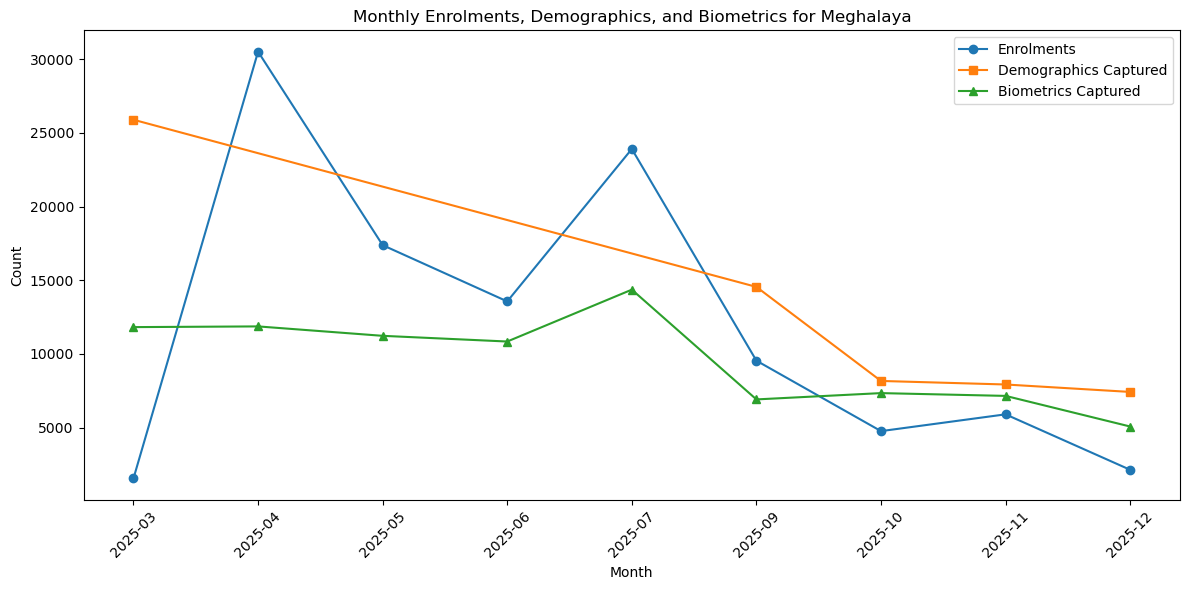

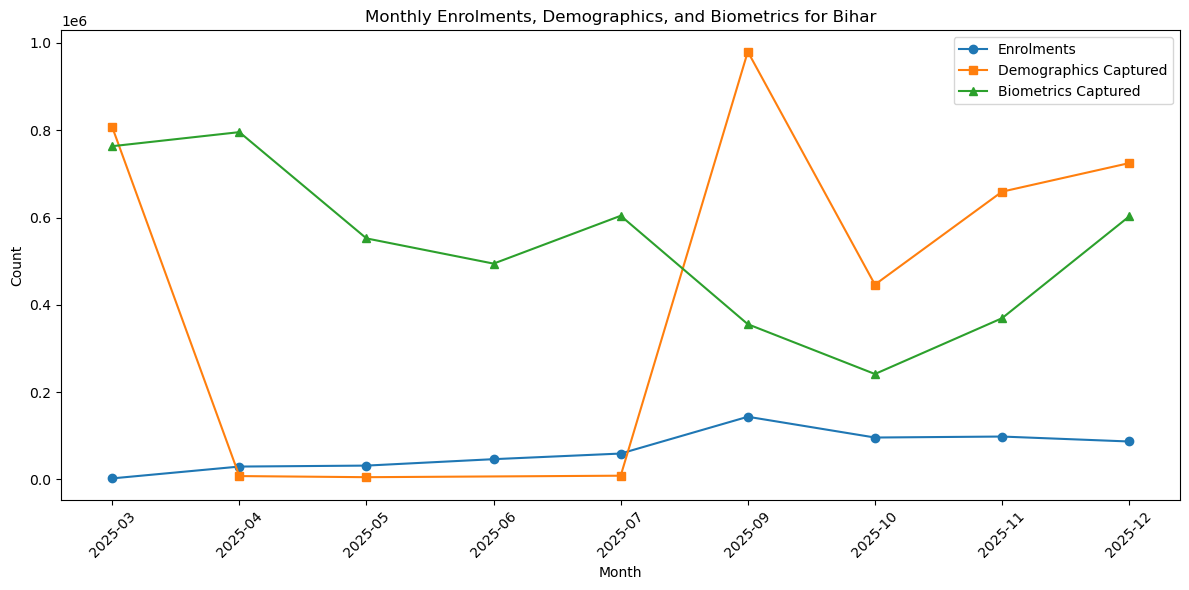

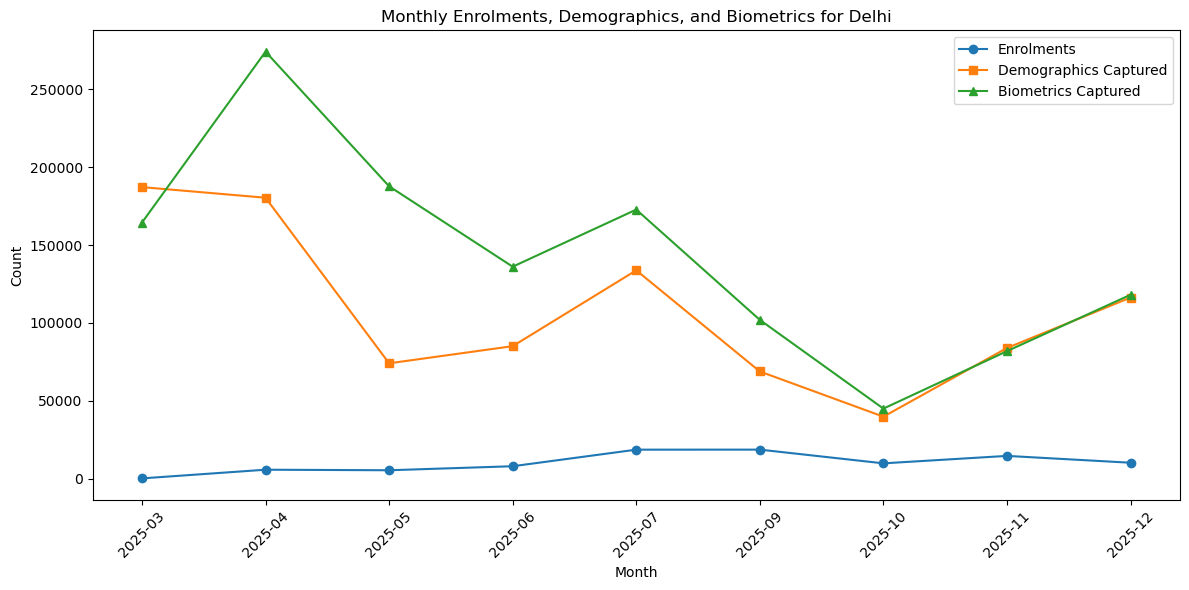

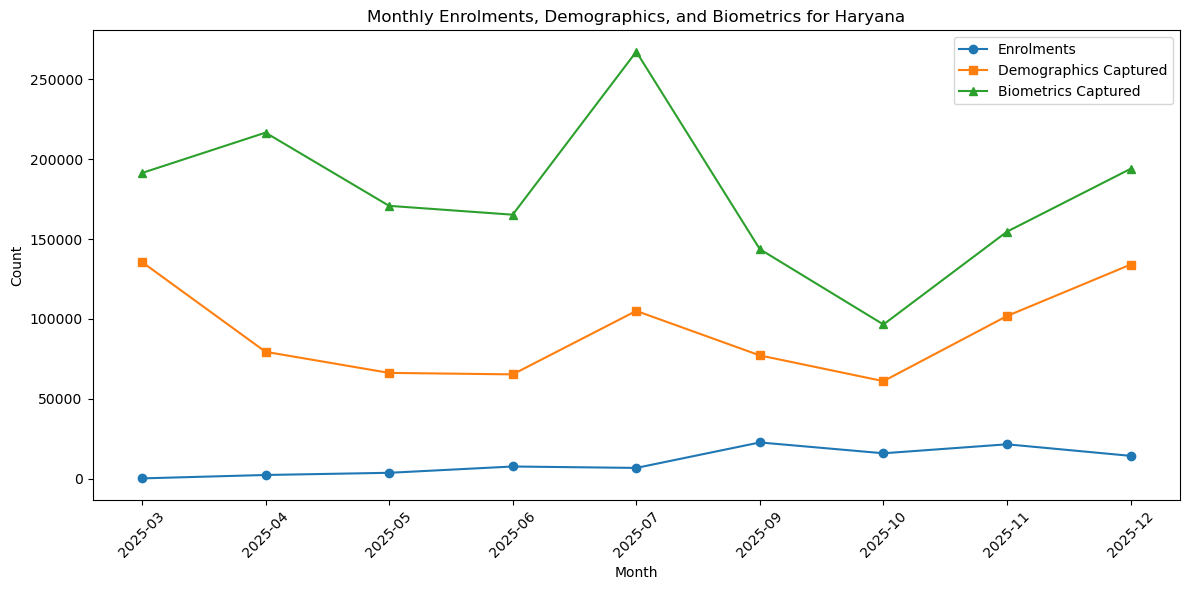

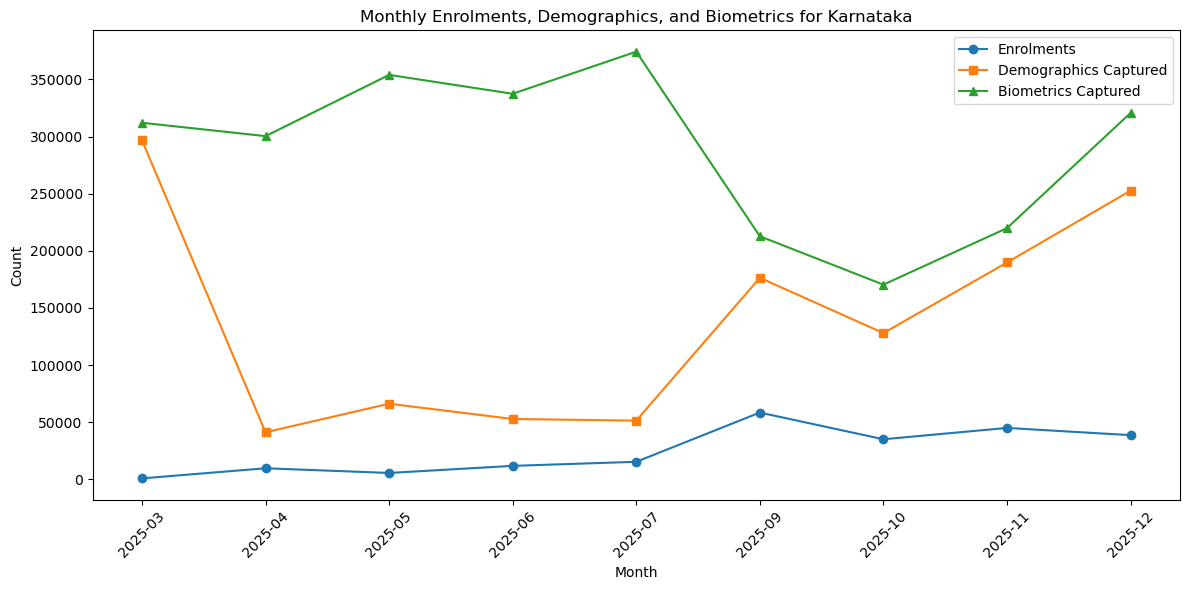

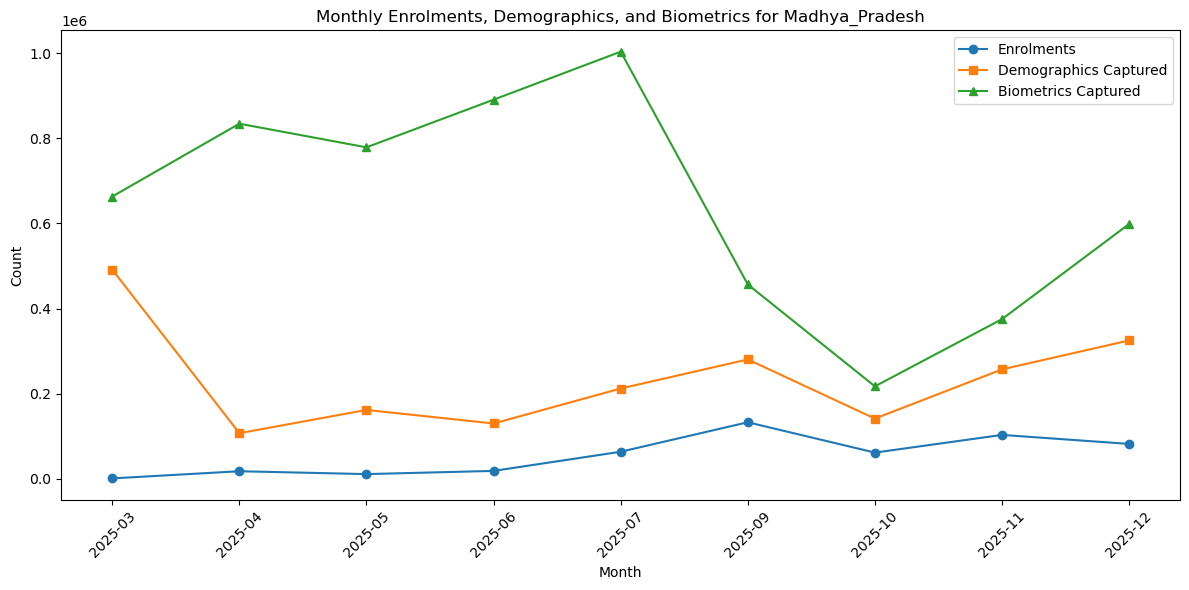

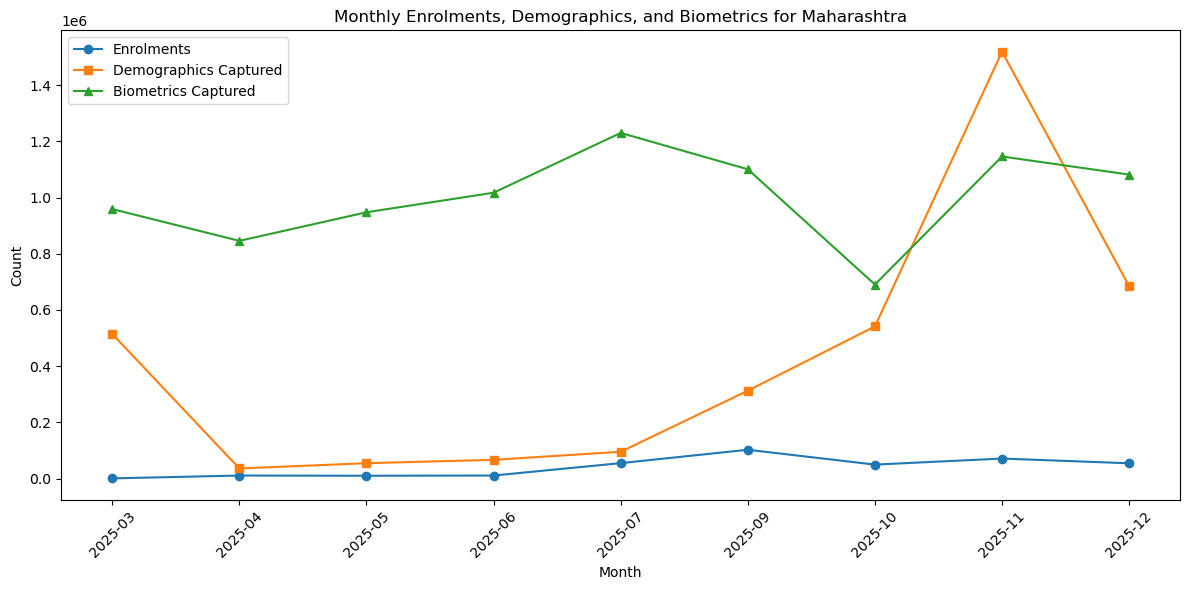

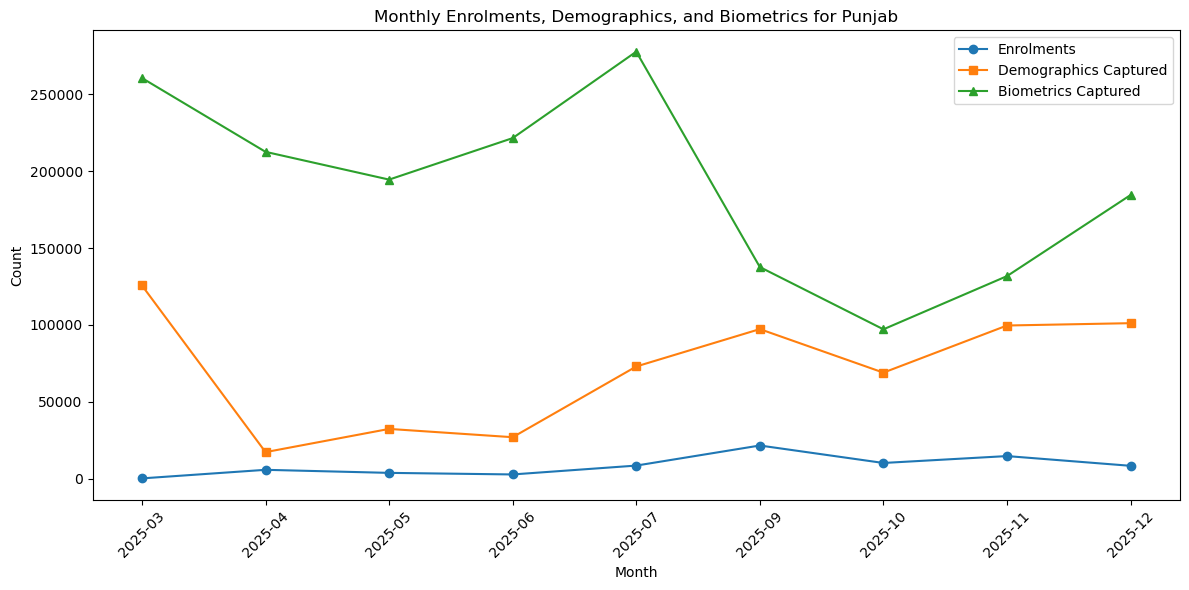

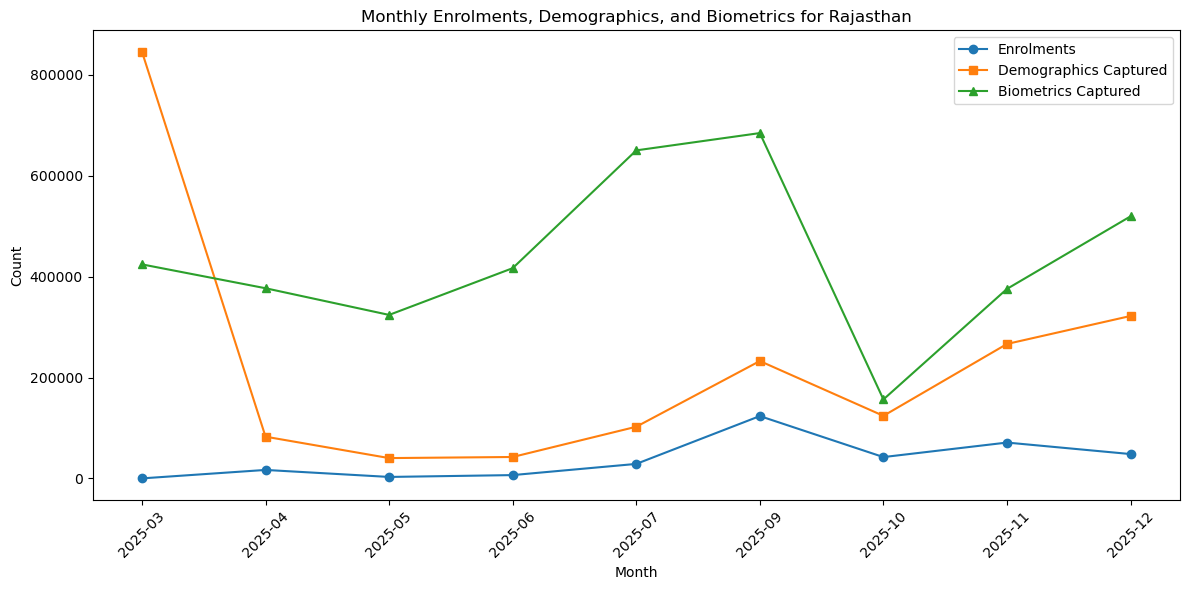

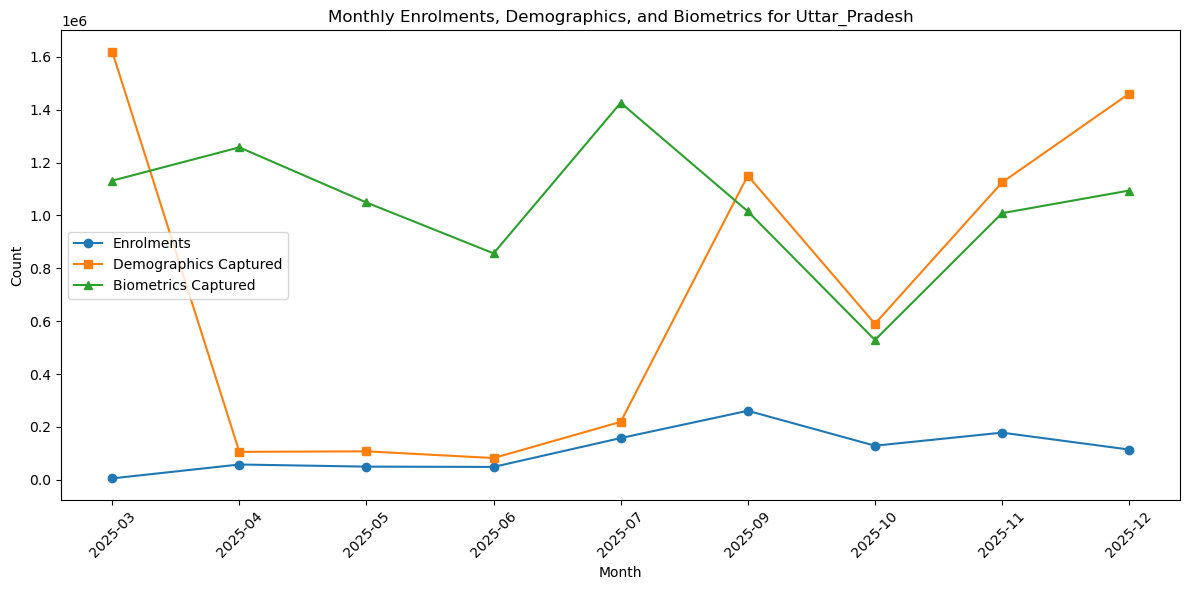

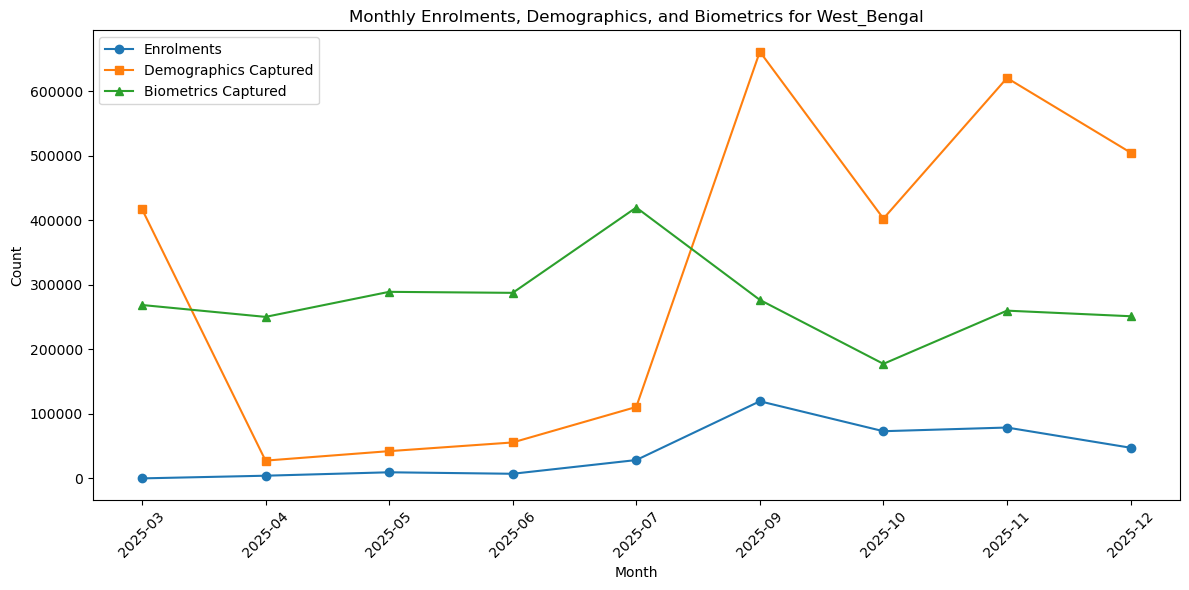

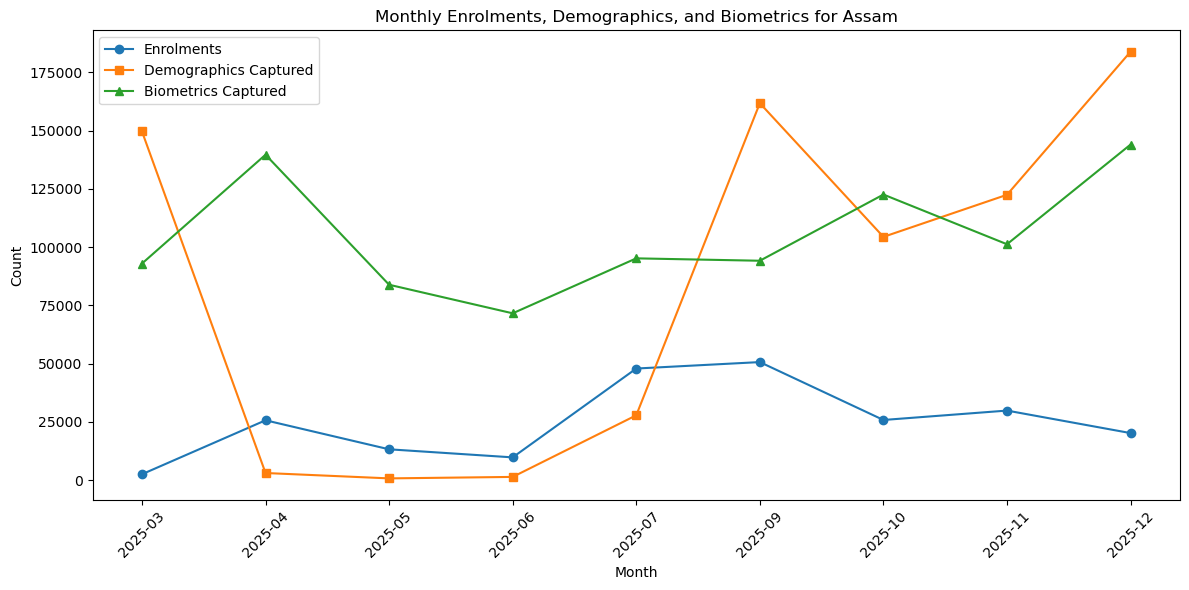

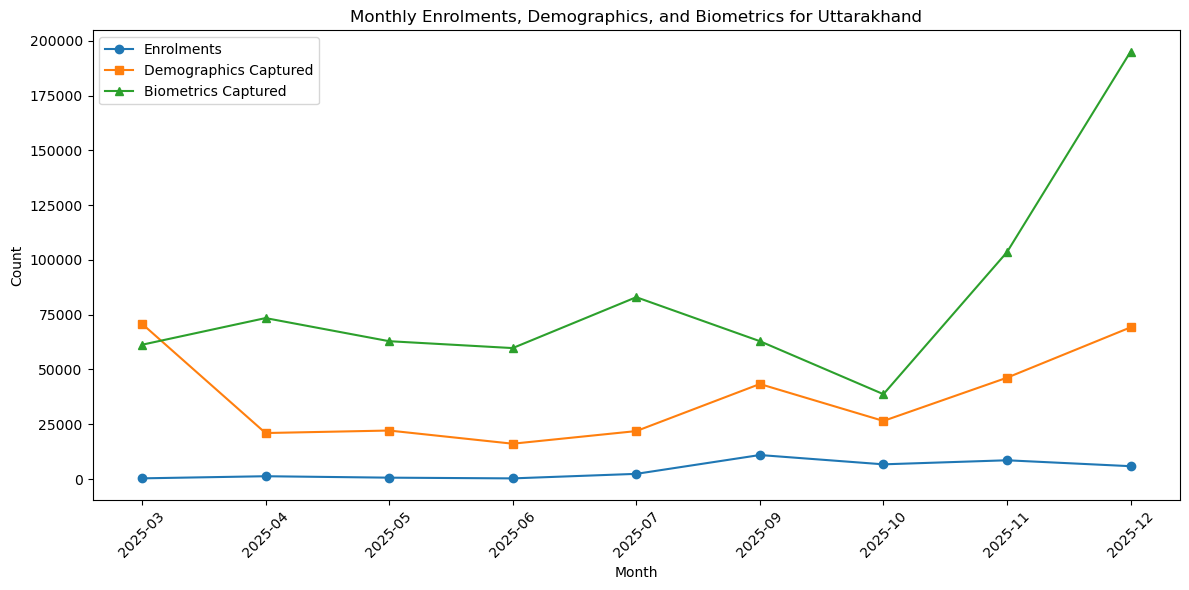

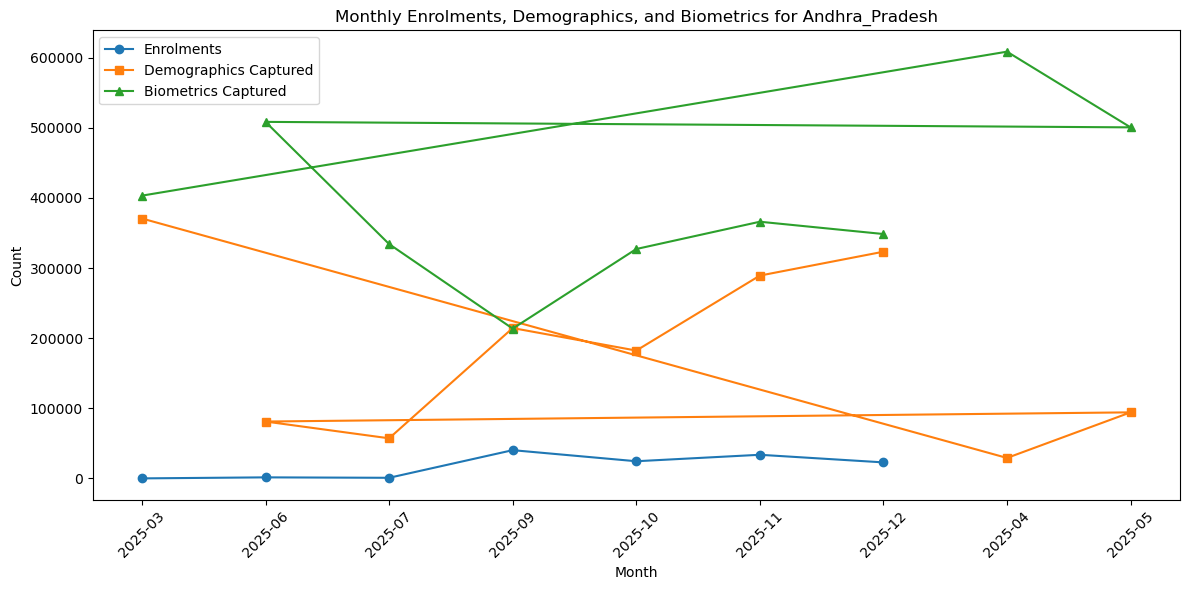

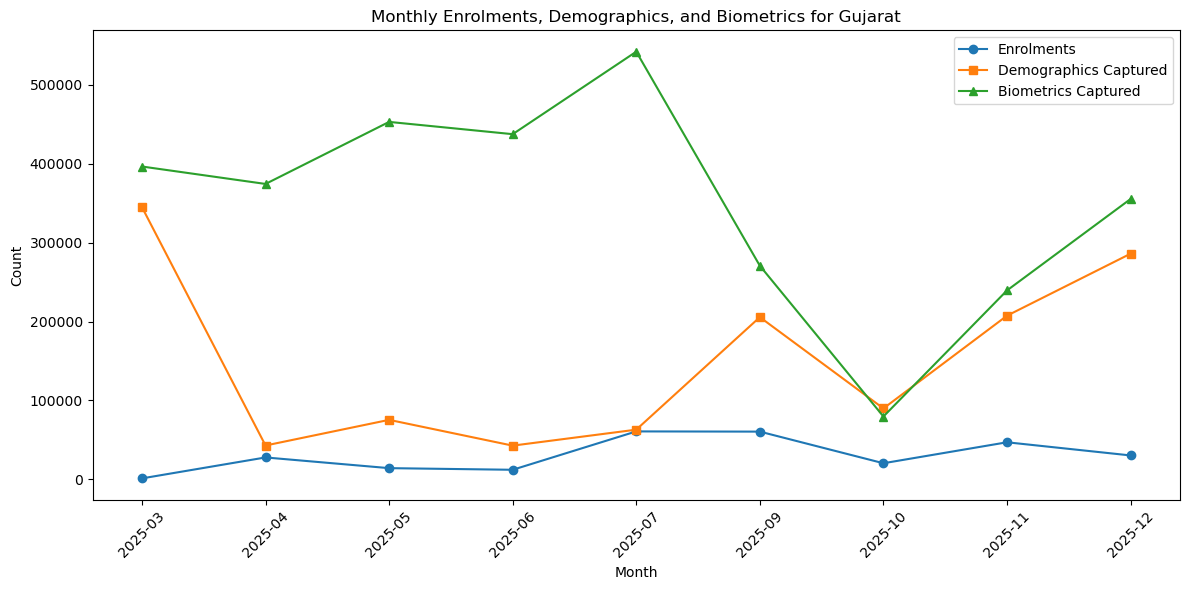

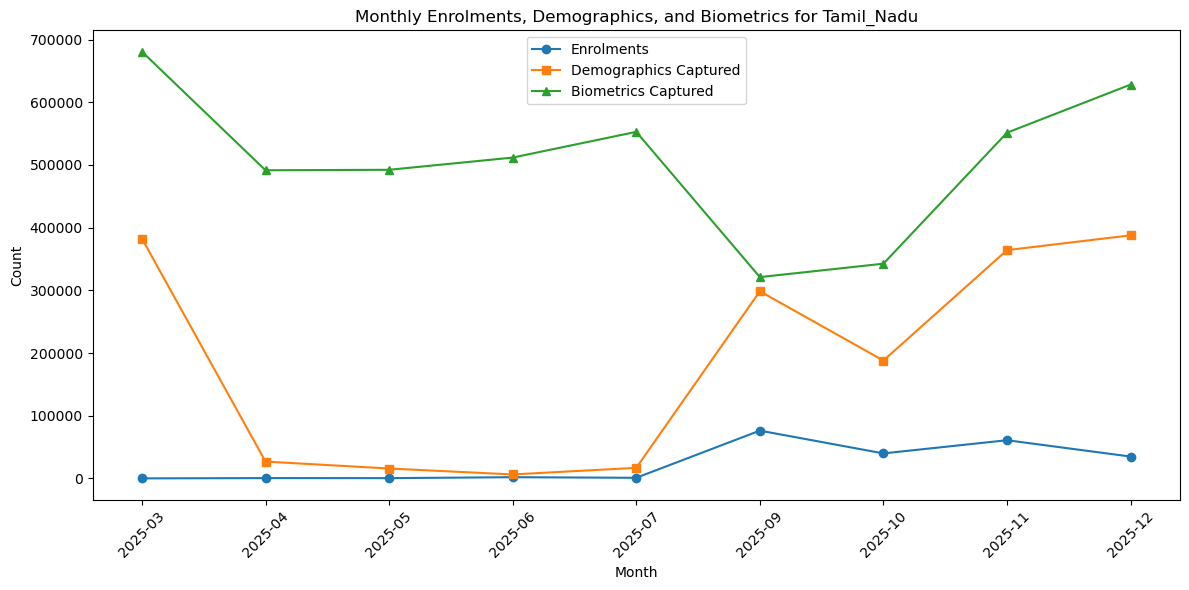

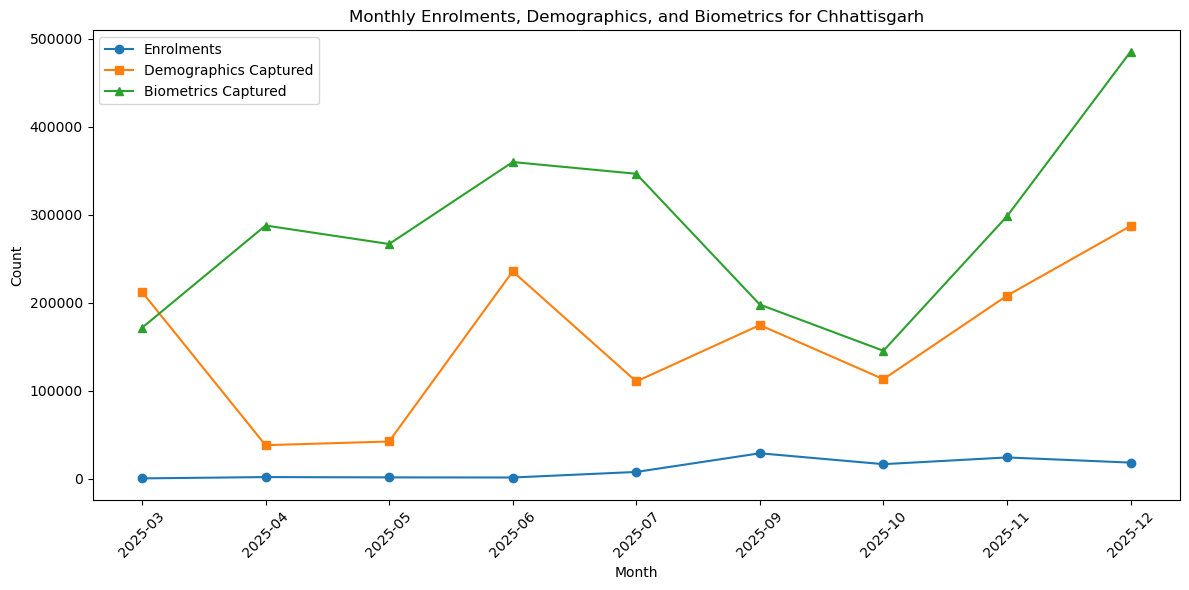

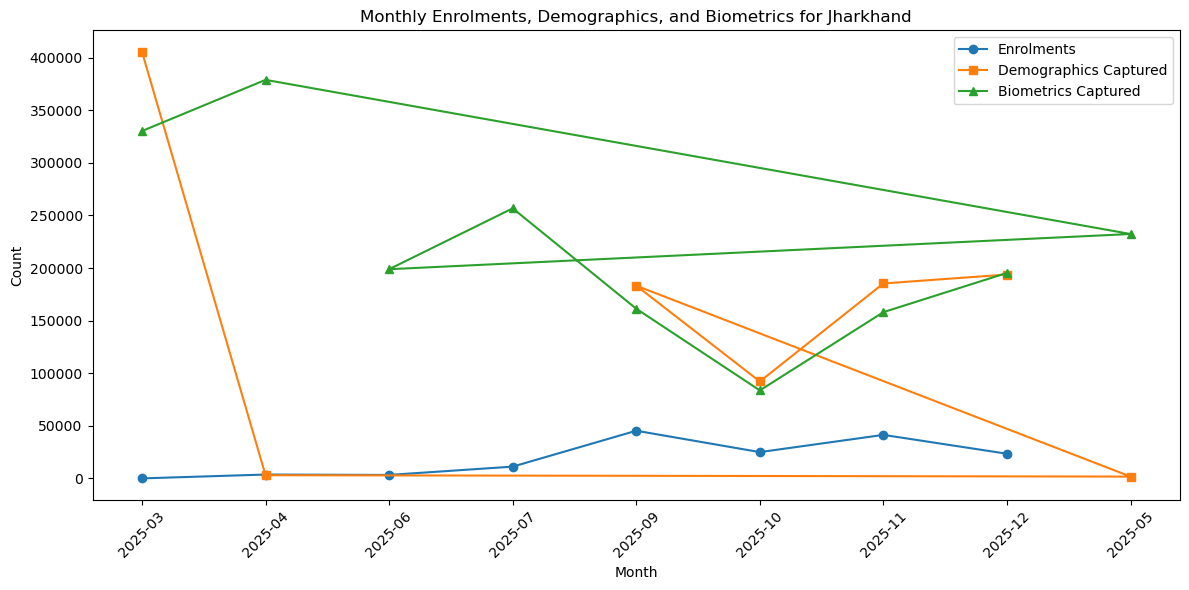

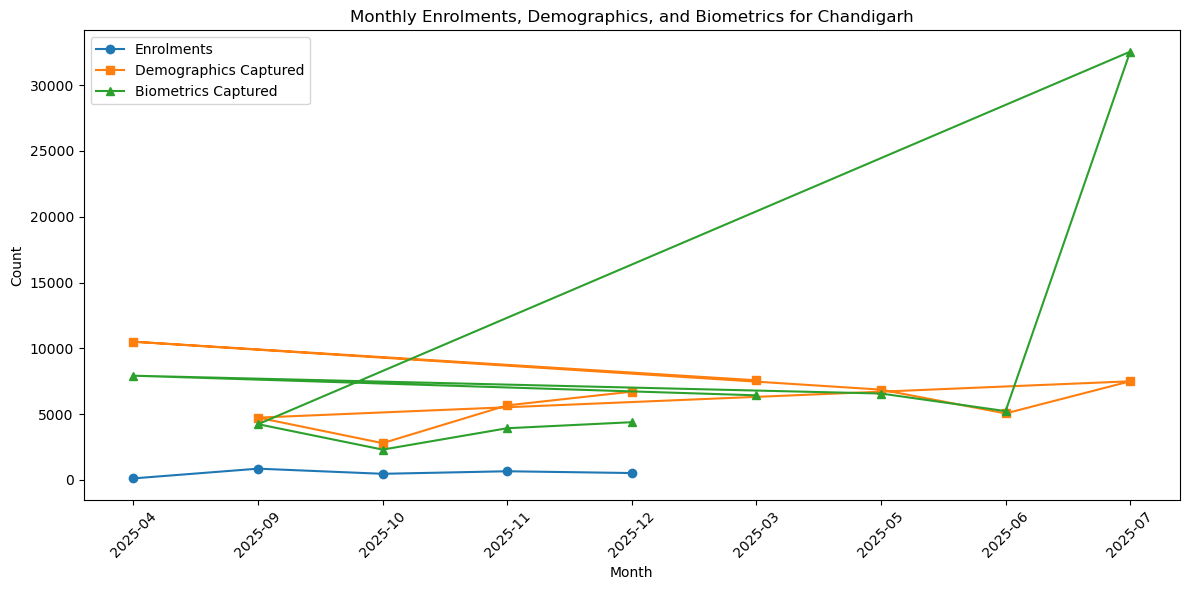

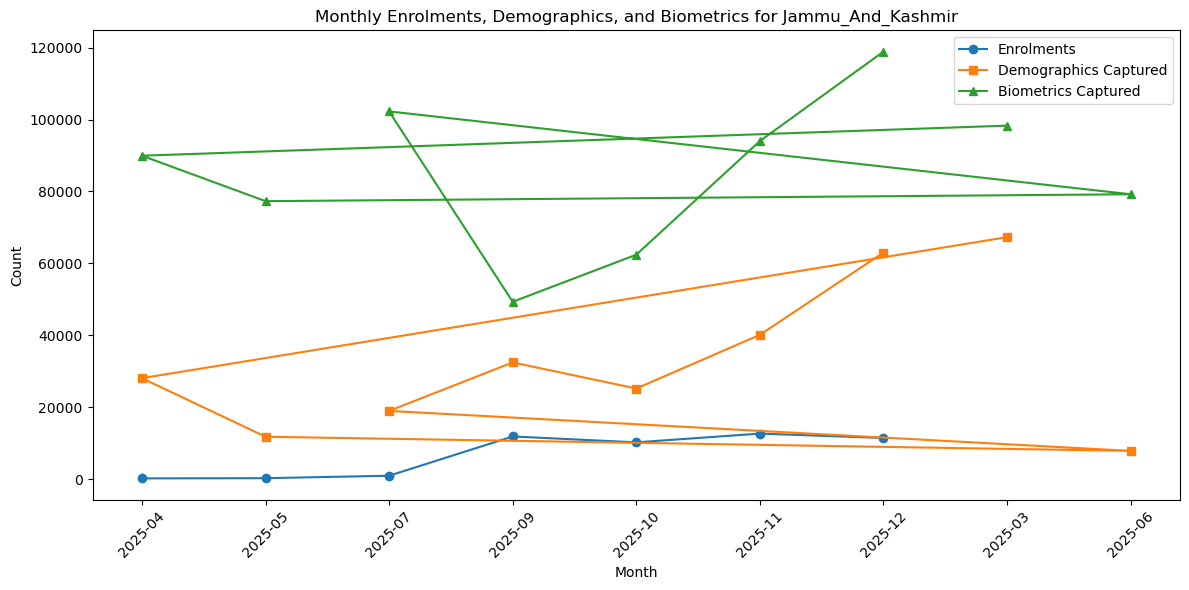

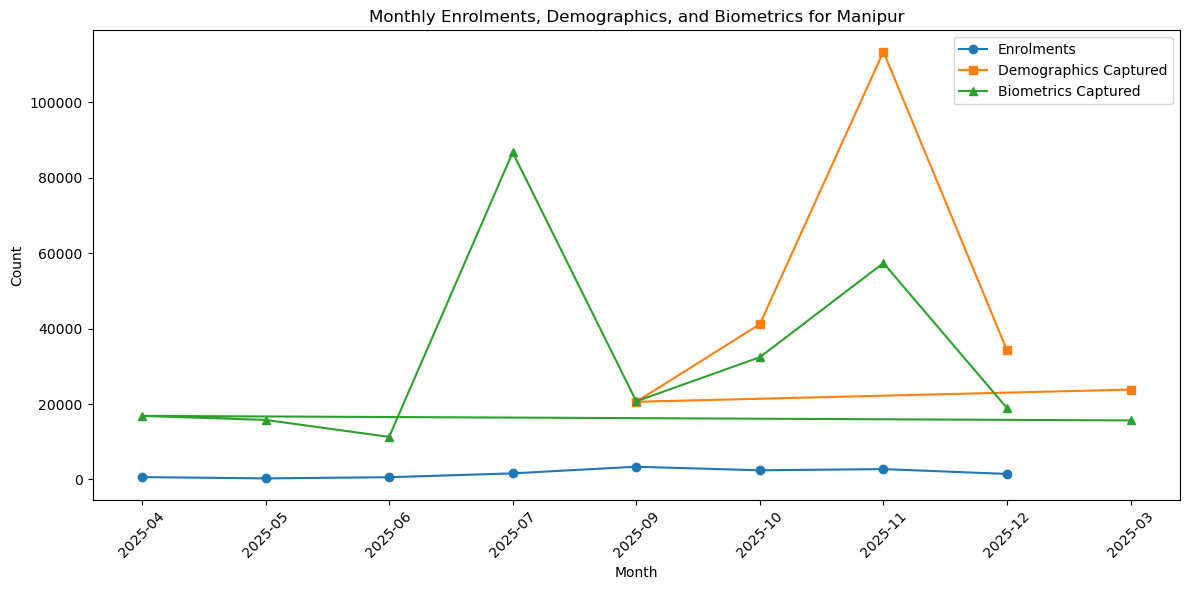

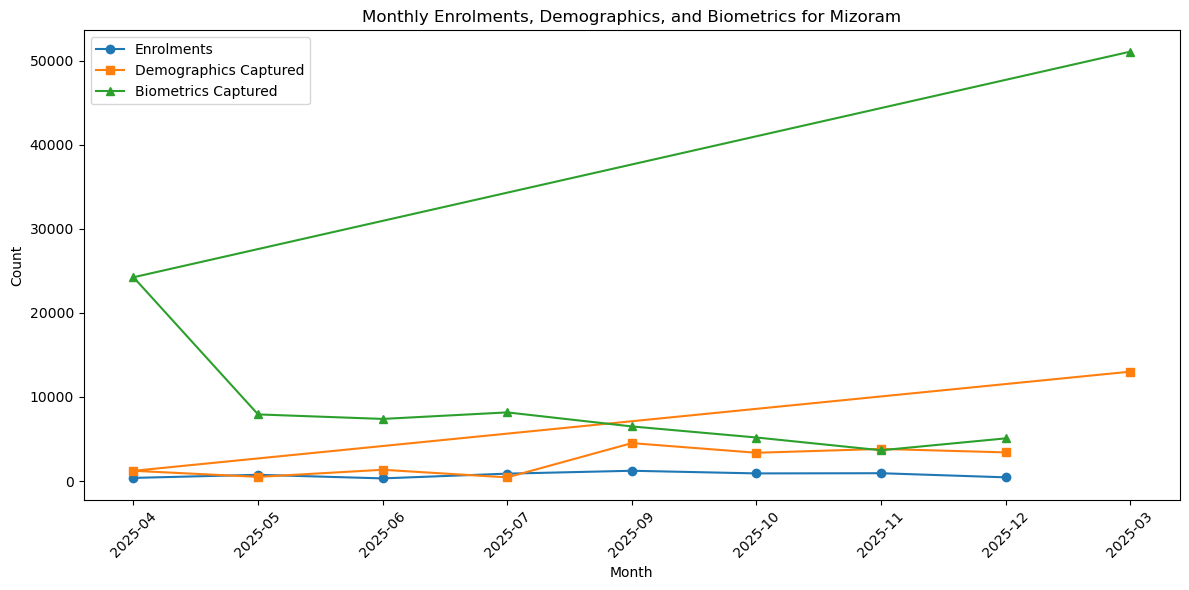

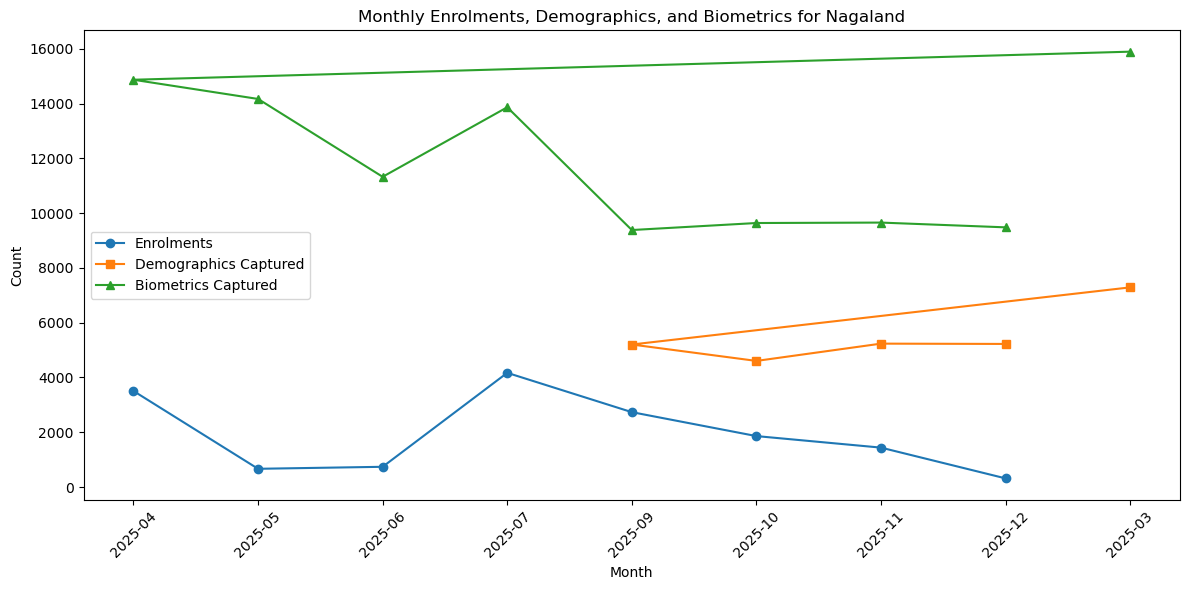

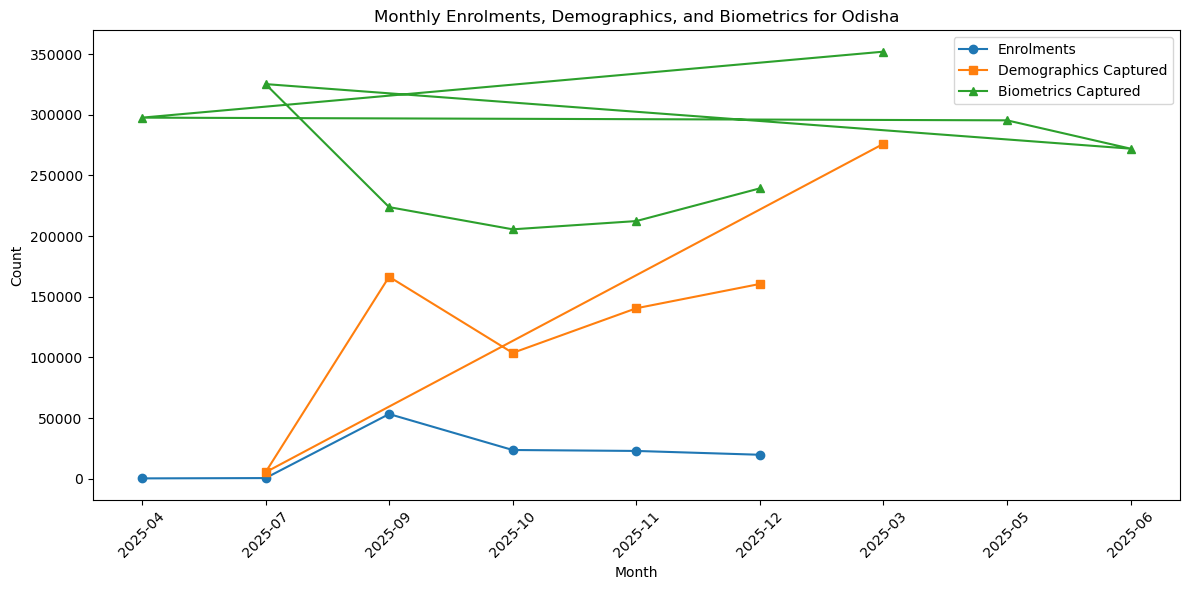

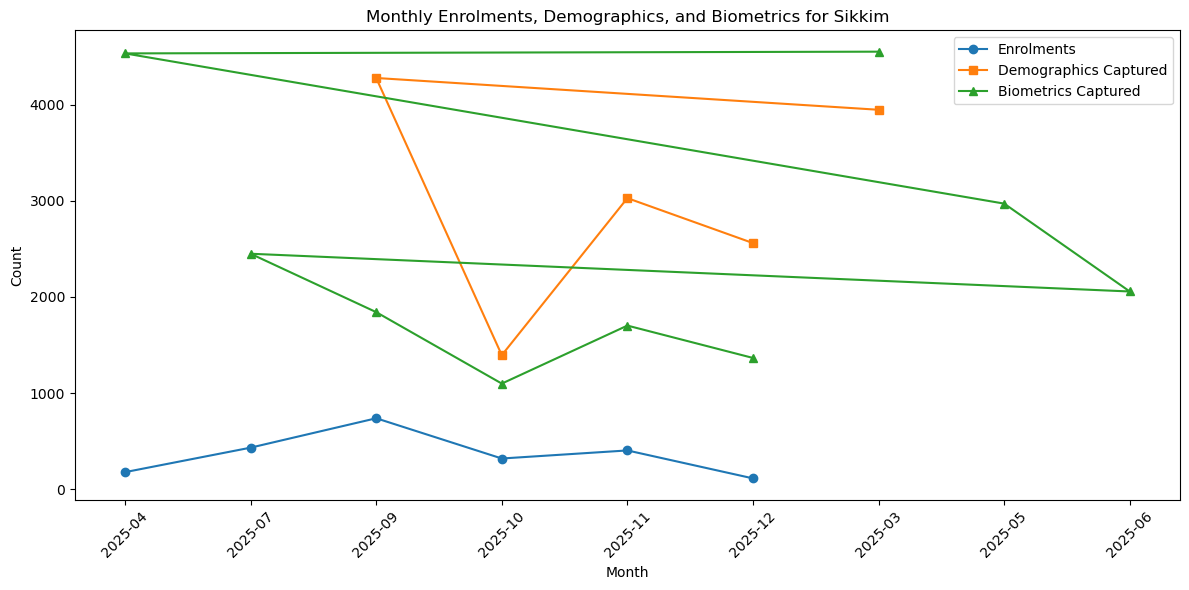

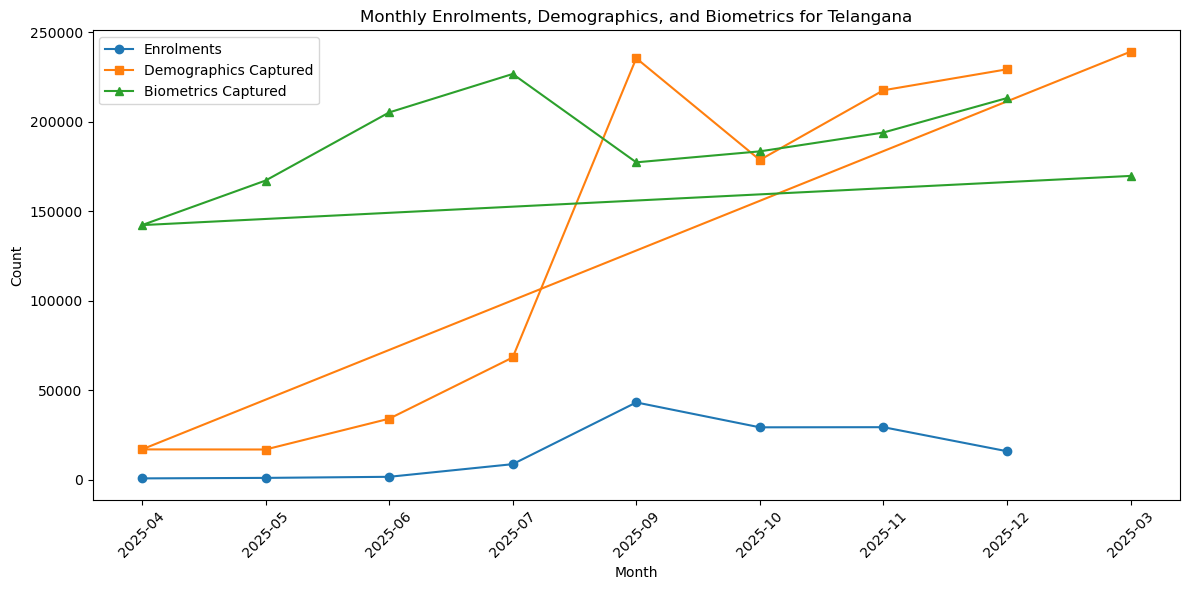

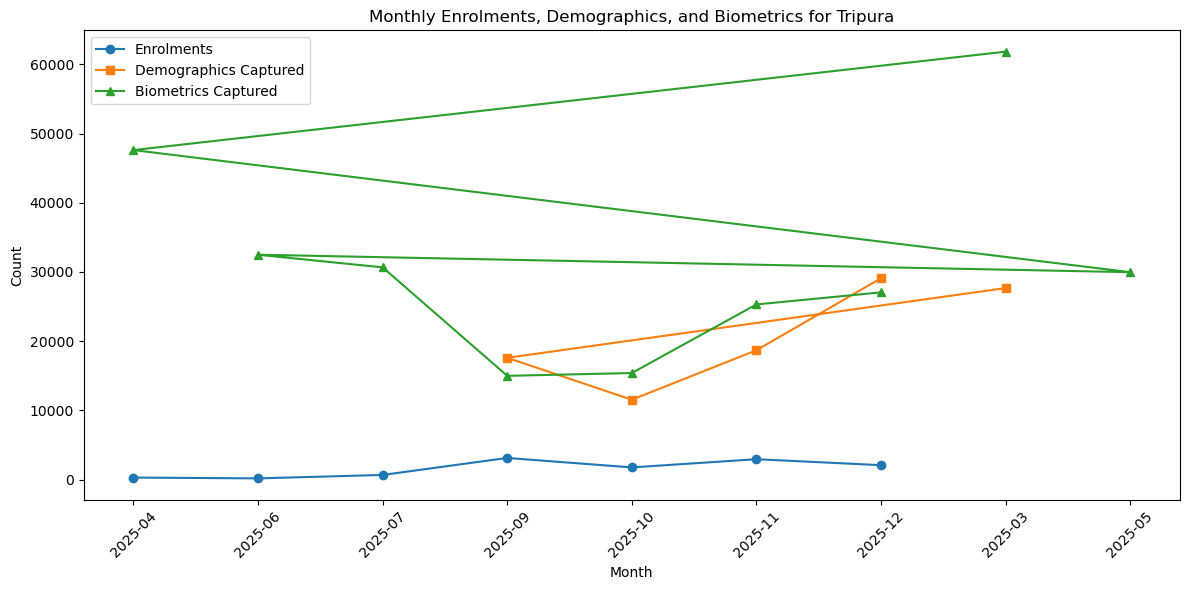

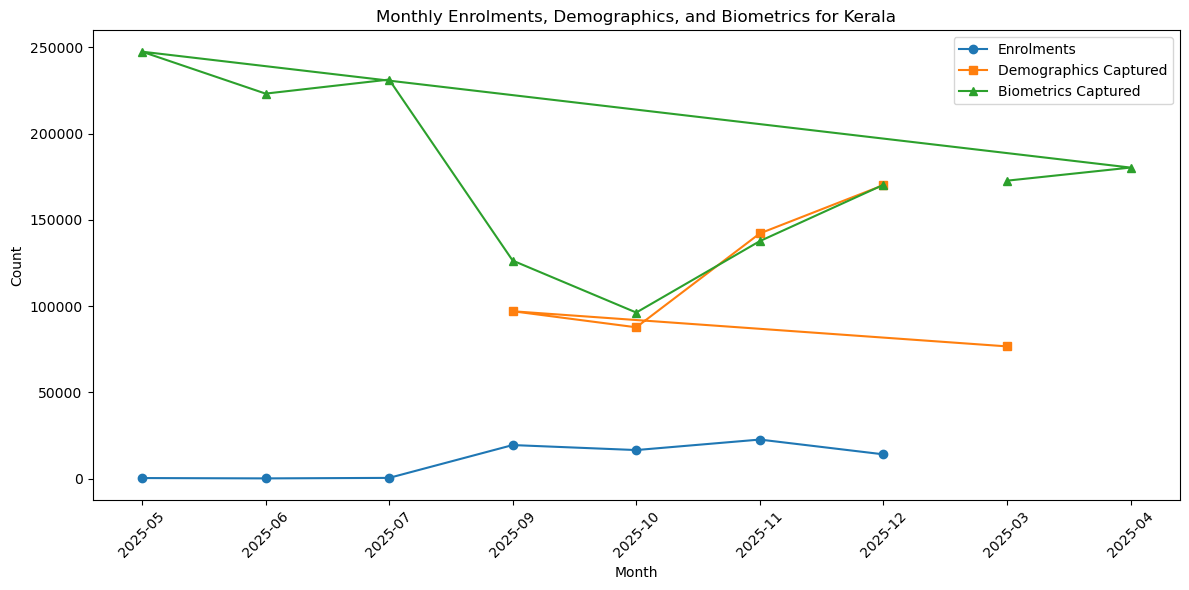

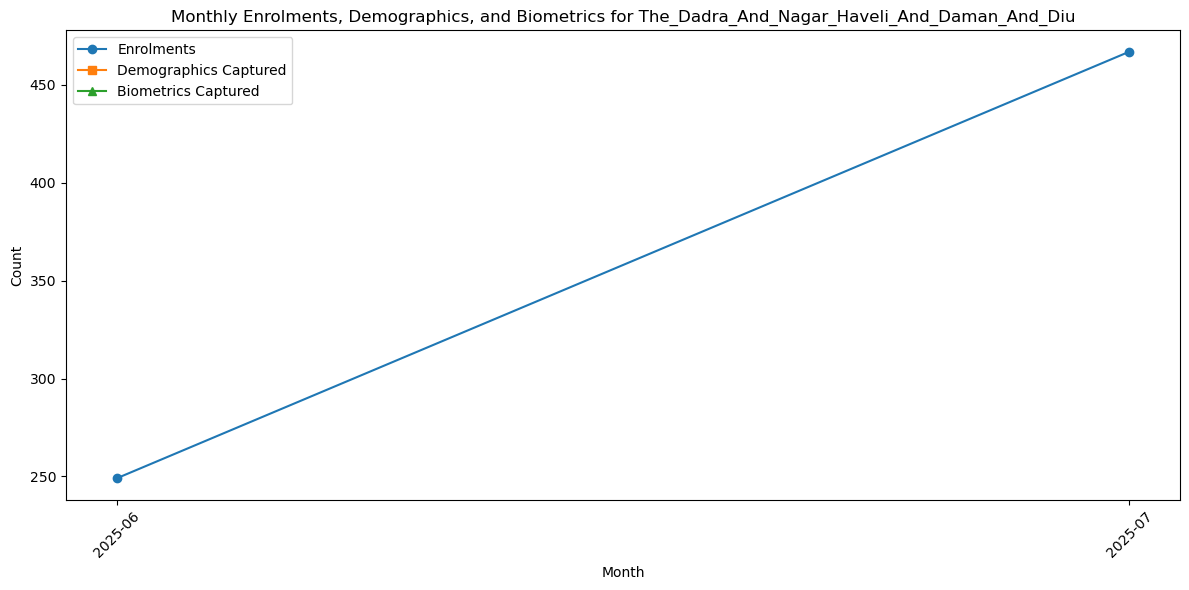

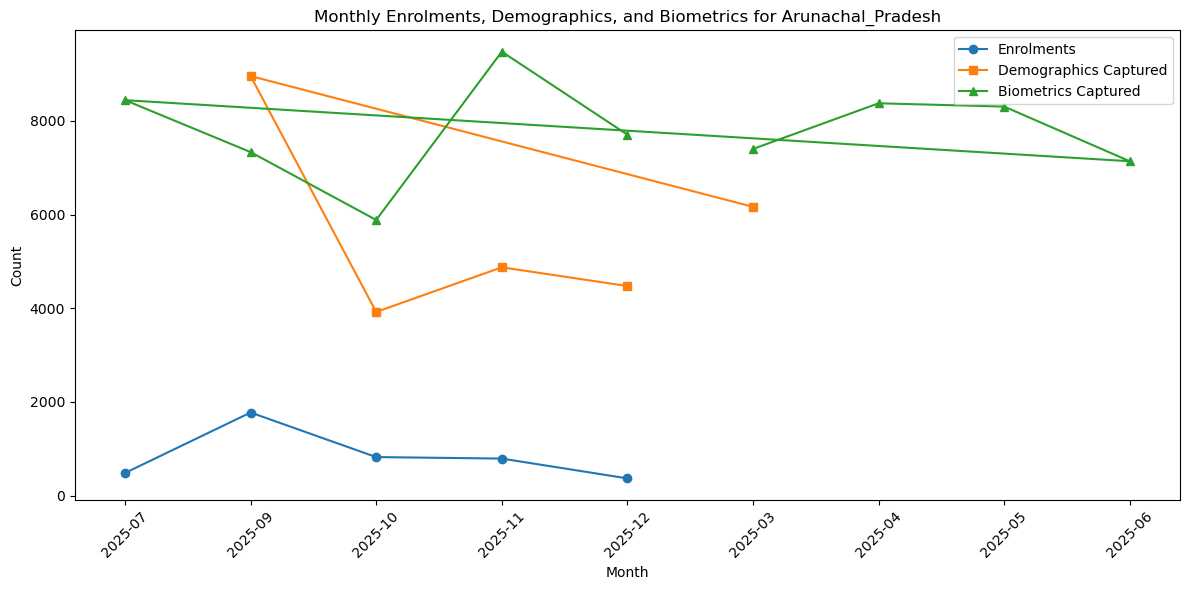

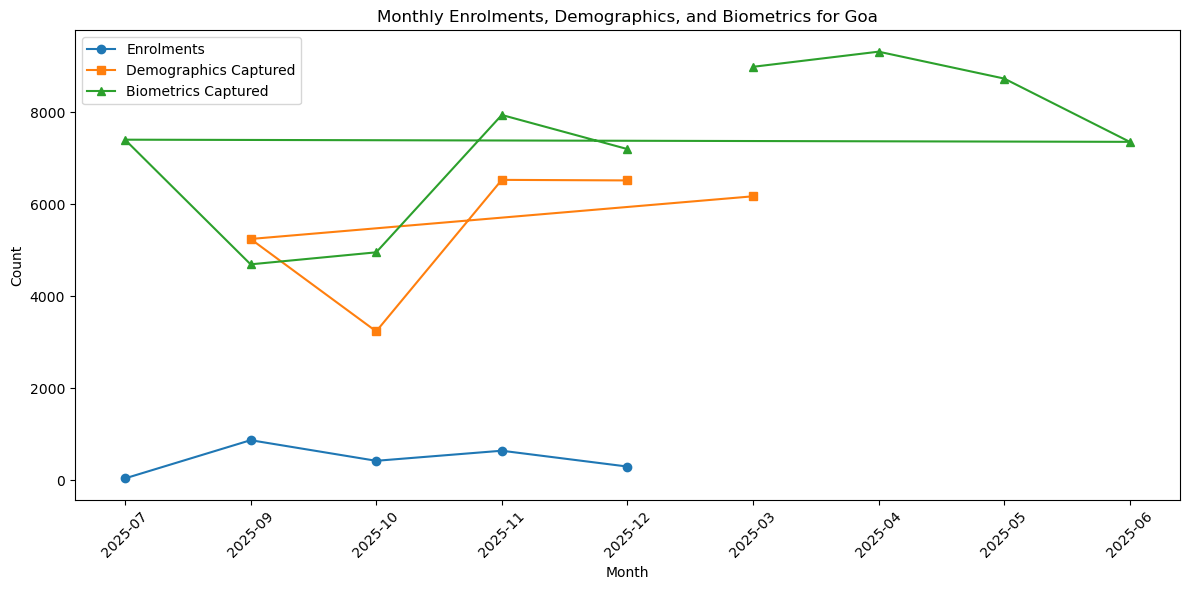

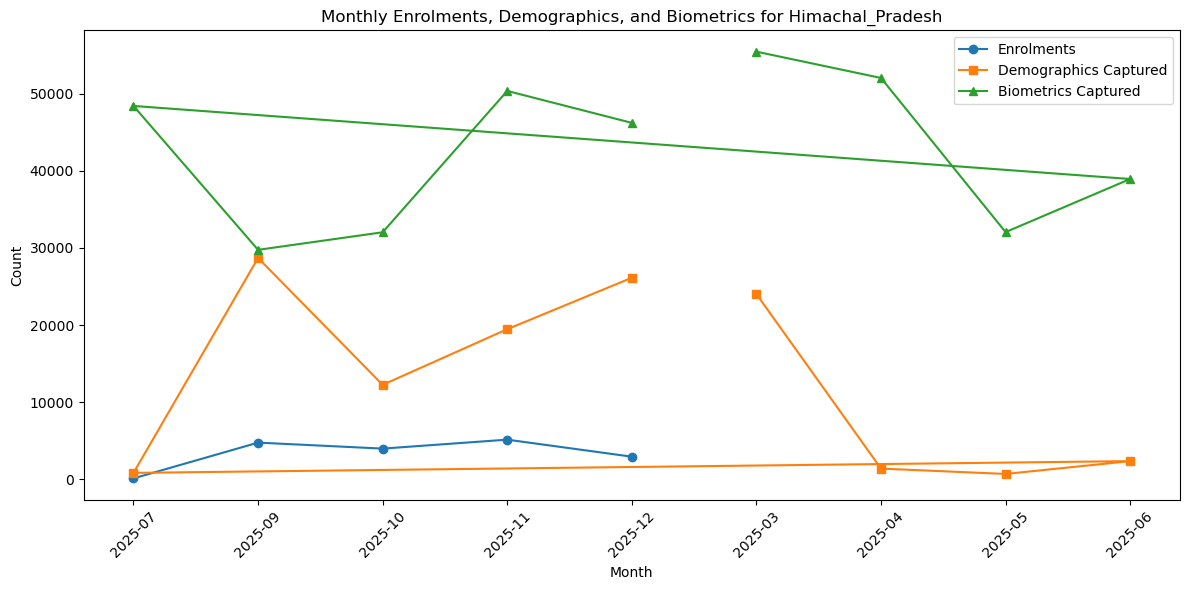

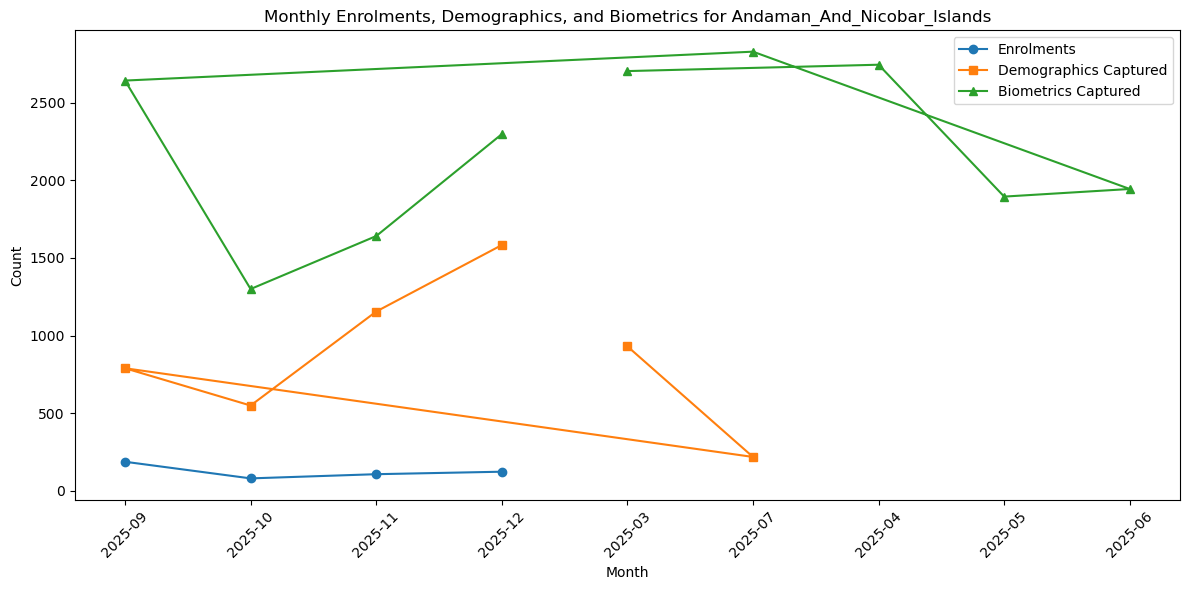

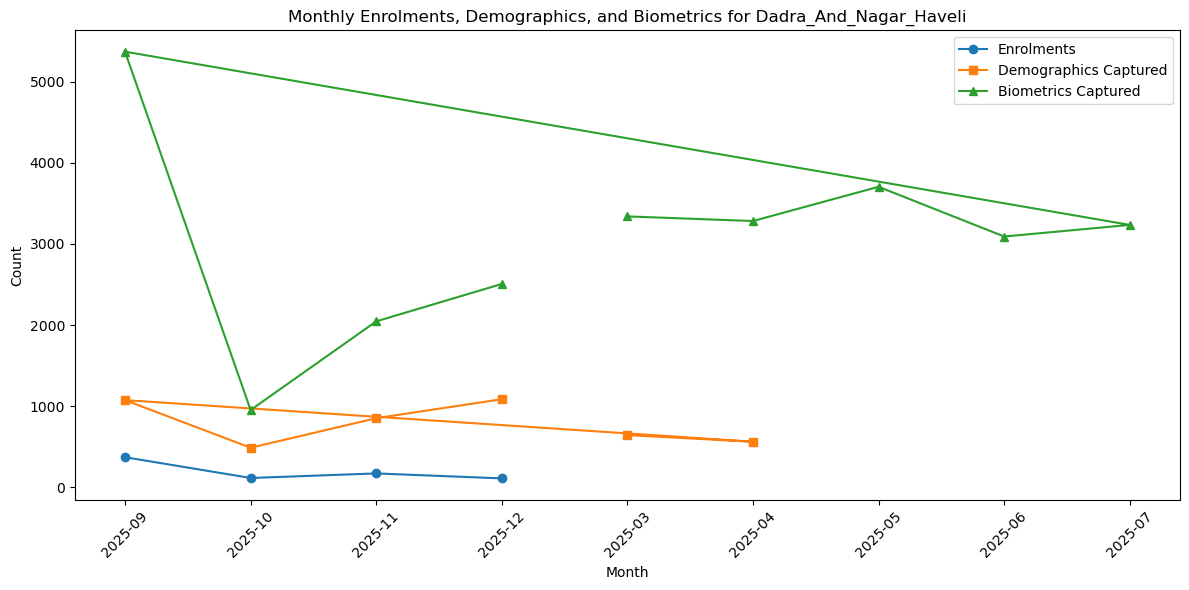

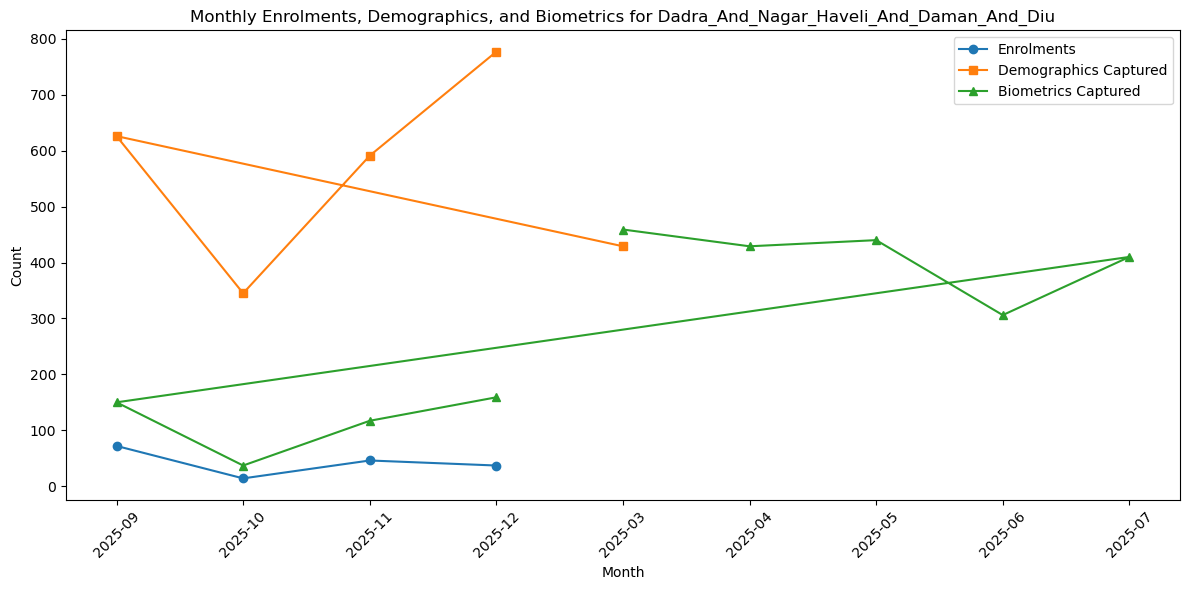

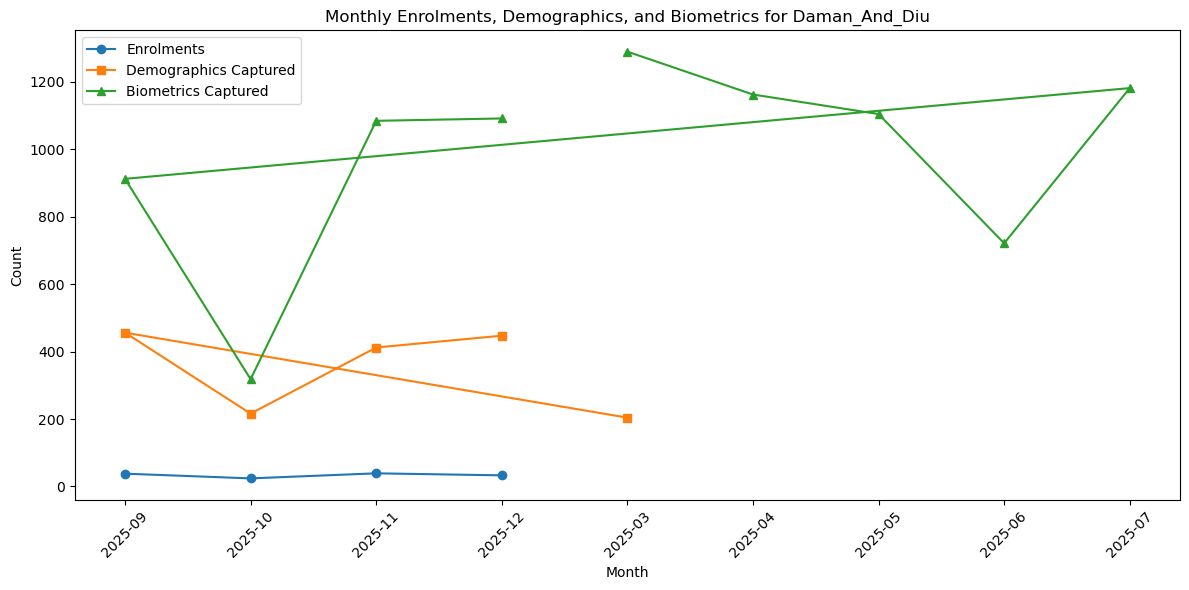

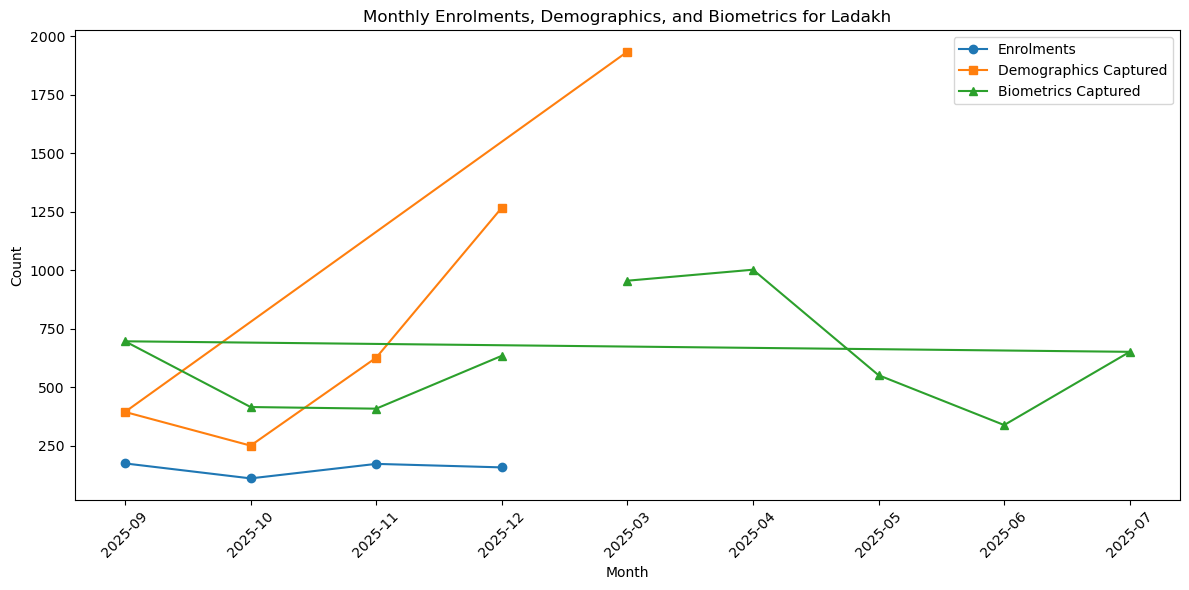

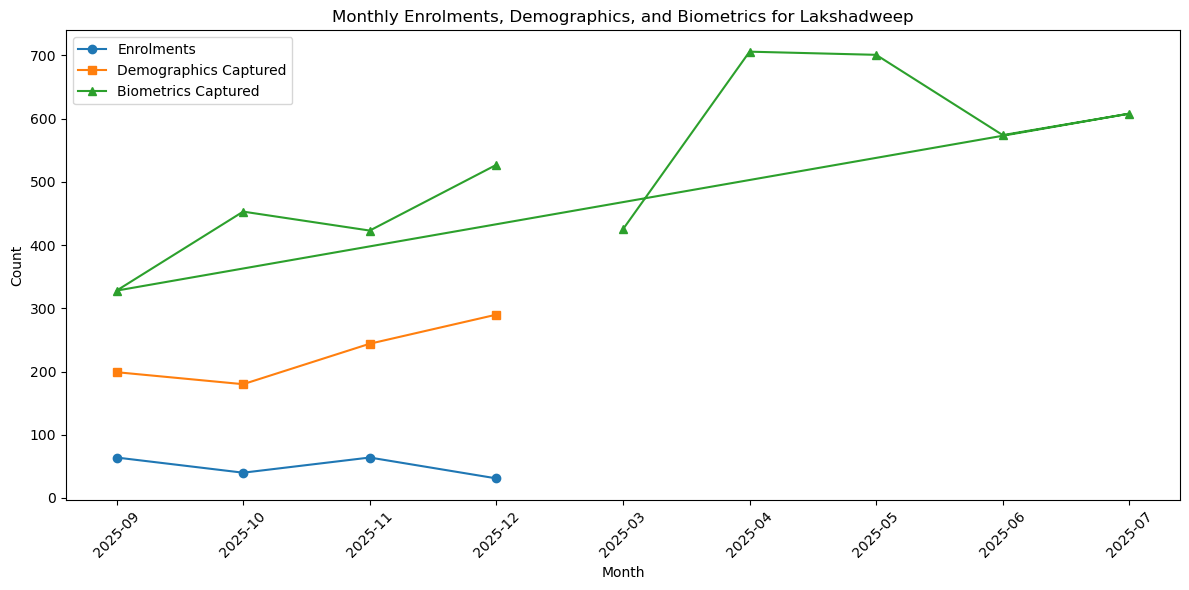

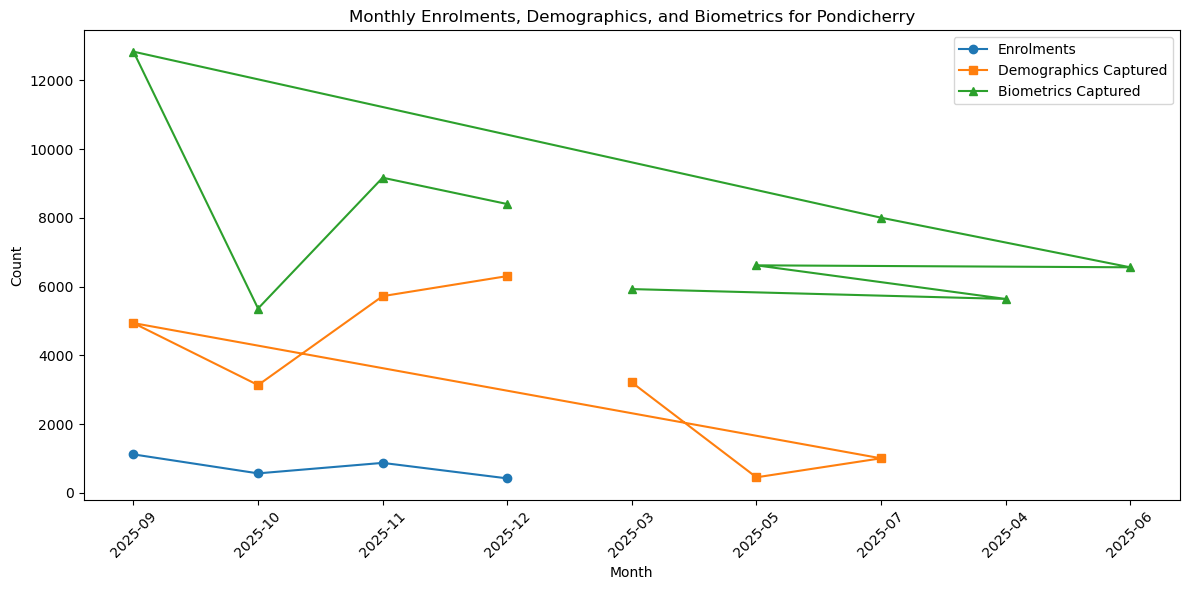

In [16]:
# Plotting  enrolments, demographics captured, and biometrics captured for each monthvise vs all states
states = df_enrol['state'].unique()
for state in states:
    plt.figure(figsize=(12, 6))
    
    # Enrolments
    plt.plot(monthly_enrolments[monthly_enrolments['state'] == state]['enrolment_month'].astype(str),
             monthly_enrolments[monthly_enrolments['state'] == state][['age_0_5', 'age_5_17', 'age_18_greater']].sum(axis=1),
             label='Enrolments', marker='o')
    
    # Demographics Captured
    plt.plot(monthly_demographics[monthly_demographics['state'] == state]['demographic_month'].astype(str),
             monthly_demographics[monthly_demographics['state'] == state][['demo_age_5_17', 'demo_age_17_']].sum(axis=1),
             label='Demographics Captured', marker='s')
    
    # Biometrics Captured
    plt.plot(monthly_biometrics[monthly_biometrics['state'] == state]['biometric_month'].astype(str),
             monthly_biometrics[monthly_biometrics['state'] == state][['bio_age_5_17', 'bio_age_17_']].sum(axis=1),
             label='Biometrics Captured', marker='^')
    
    plt.title(f'Monthly Enrolments, Demographics, and Biometrics for {state}')
    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

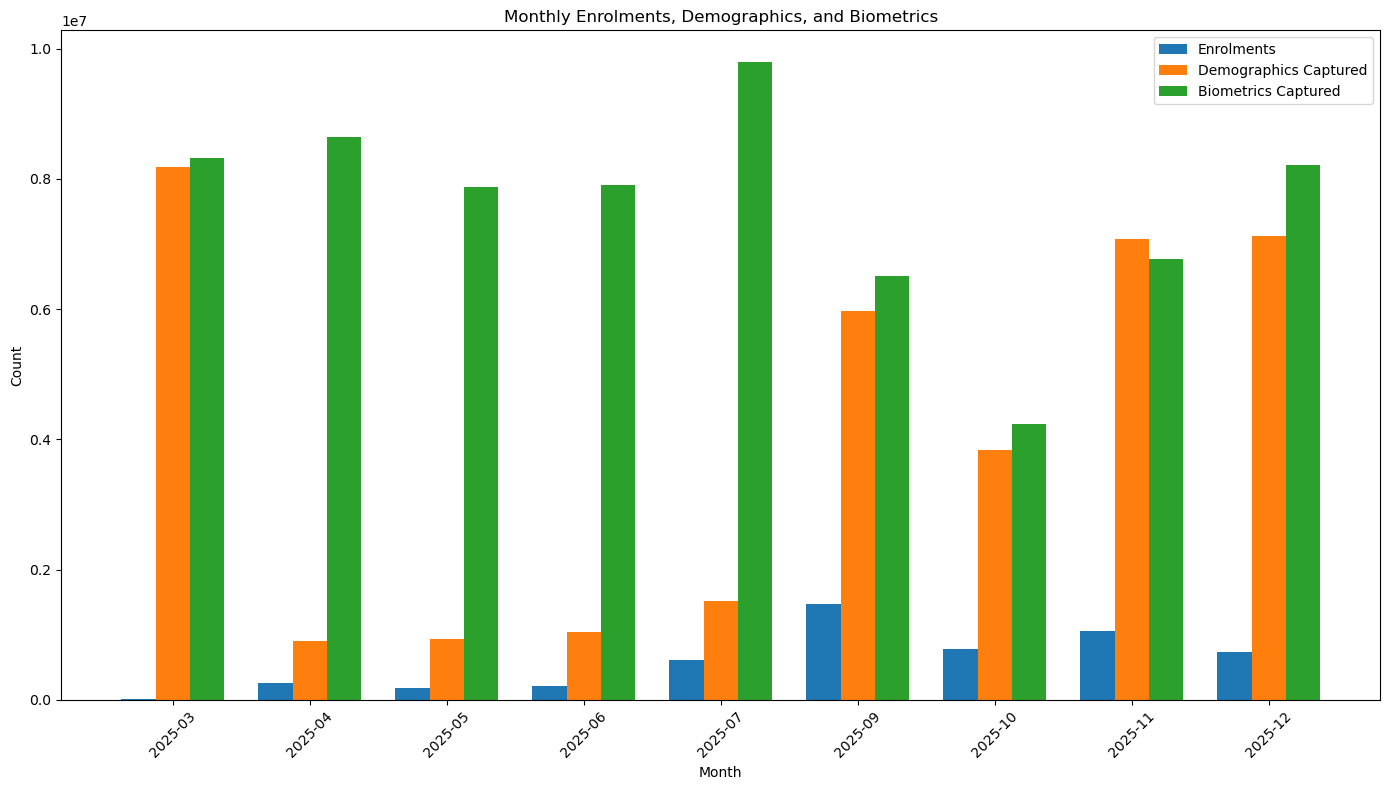

In [17]:
# Plotting  enrolments, demographics captured, and biometrics captured for each monthvise vs all states in one bar graph
plt.figure(figsize=(14, 8))
width = 0.25
months = monthly_enrolments['enrolment_month'].astype(str).unique()
x = np.arange(len(months))
enrolment_counts = monthly_enrolments.groupby('enrolment_month')[['age_0_5', 'age_5_17', 'age_18_greater']].sum().sum(axis=1).values
demographic_counts = monthly_demographics.groupby('demographic_month')[['demo_age_5_17', 'demo_age_17_']].sum().sum(axis=1).values
biometric_counts = monthly_biometrics.groupby('biometric_month')[['bio_age_5_17', 'bio_age_17_']].sum().sum(axis=1).values
plt.bar(x - width, enrolment_counts, width, label='Enrolments')
plt.bar(x, demographic_counts, width, label='Demographics Captured')
plt.bar(x + width, biometric_counts, width, label='Biometrics Captured')
plt.xlabel('Month') 
plt.ylabel('Count')
plt.title('Monthly Enrolments, Demographics, and Biometrics')
plt.xticks(x, months, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

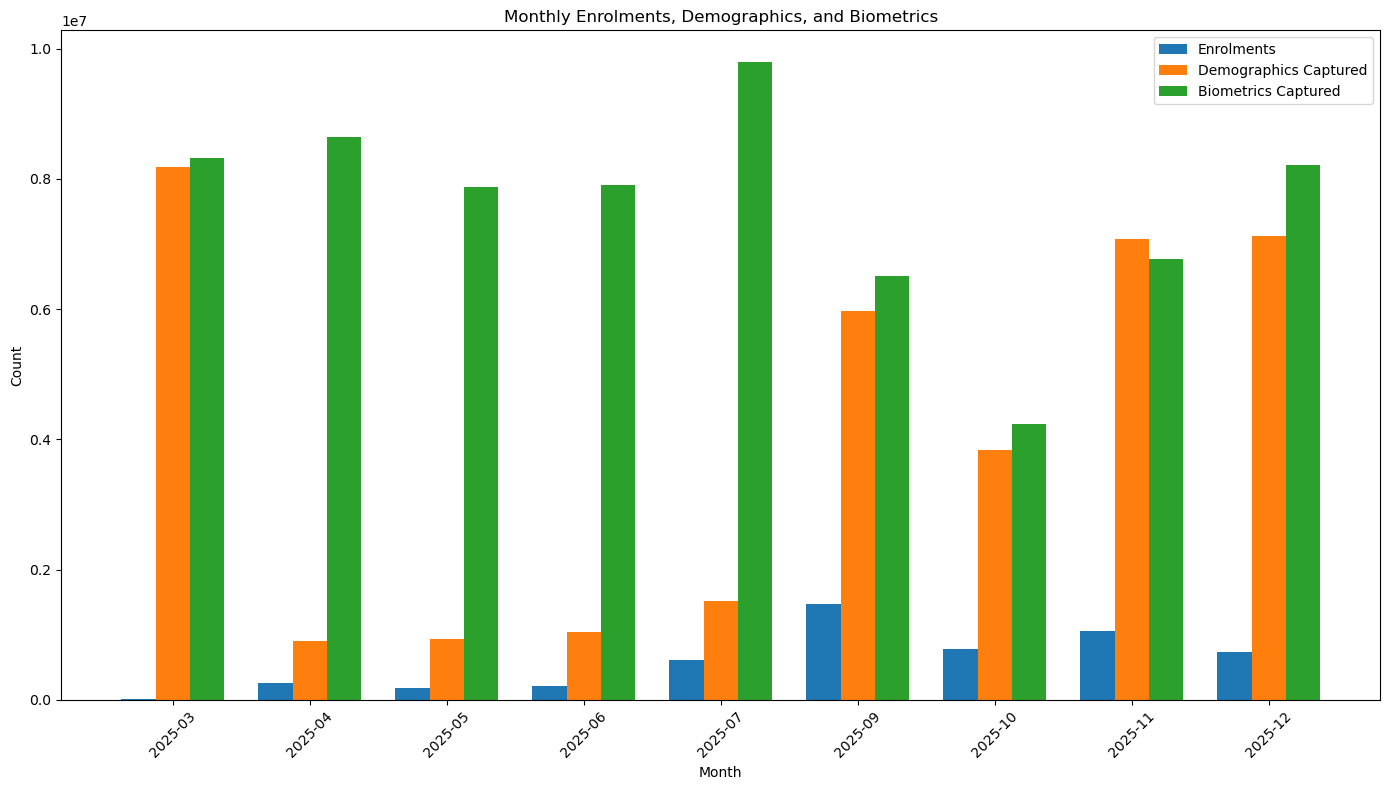

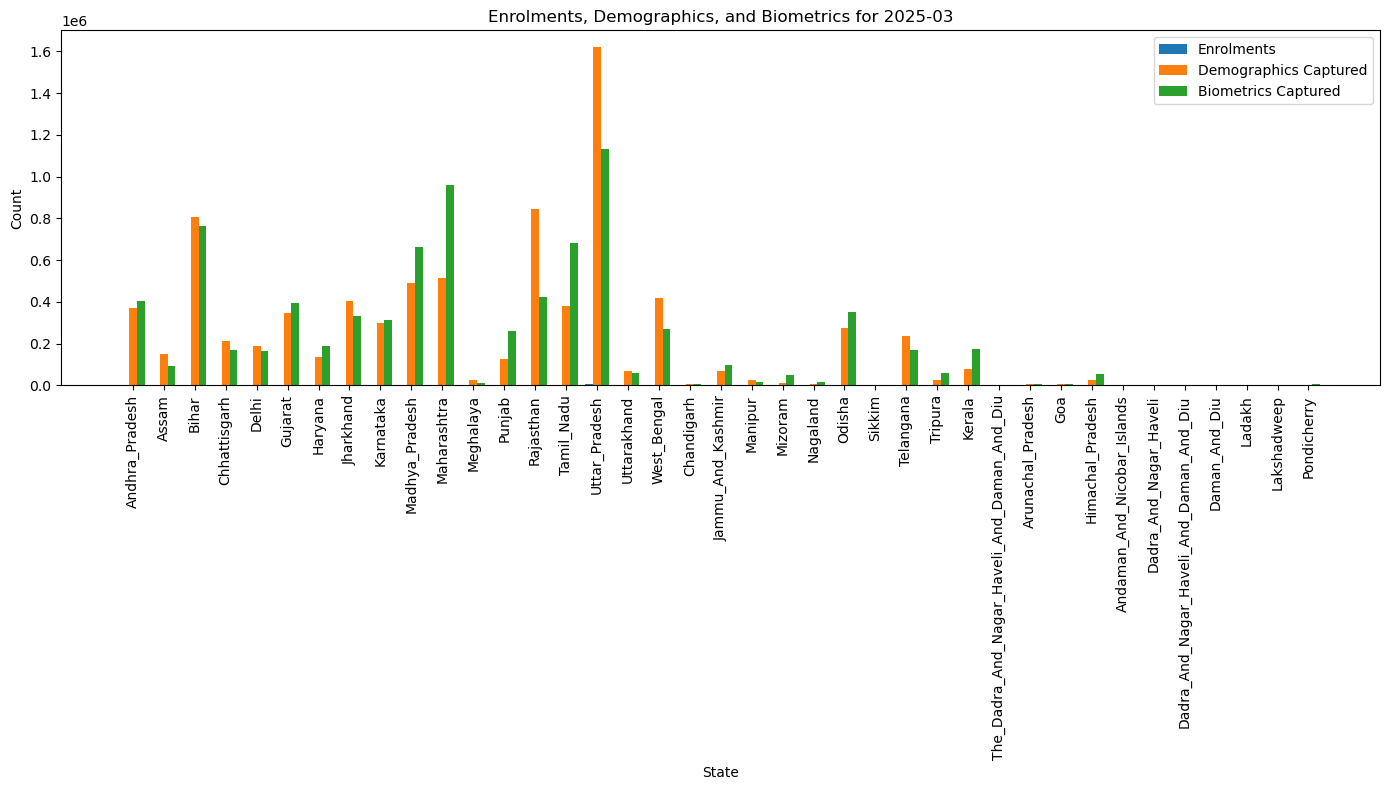

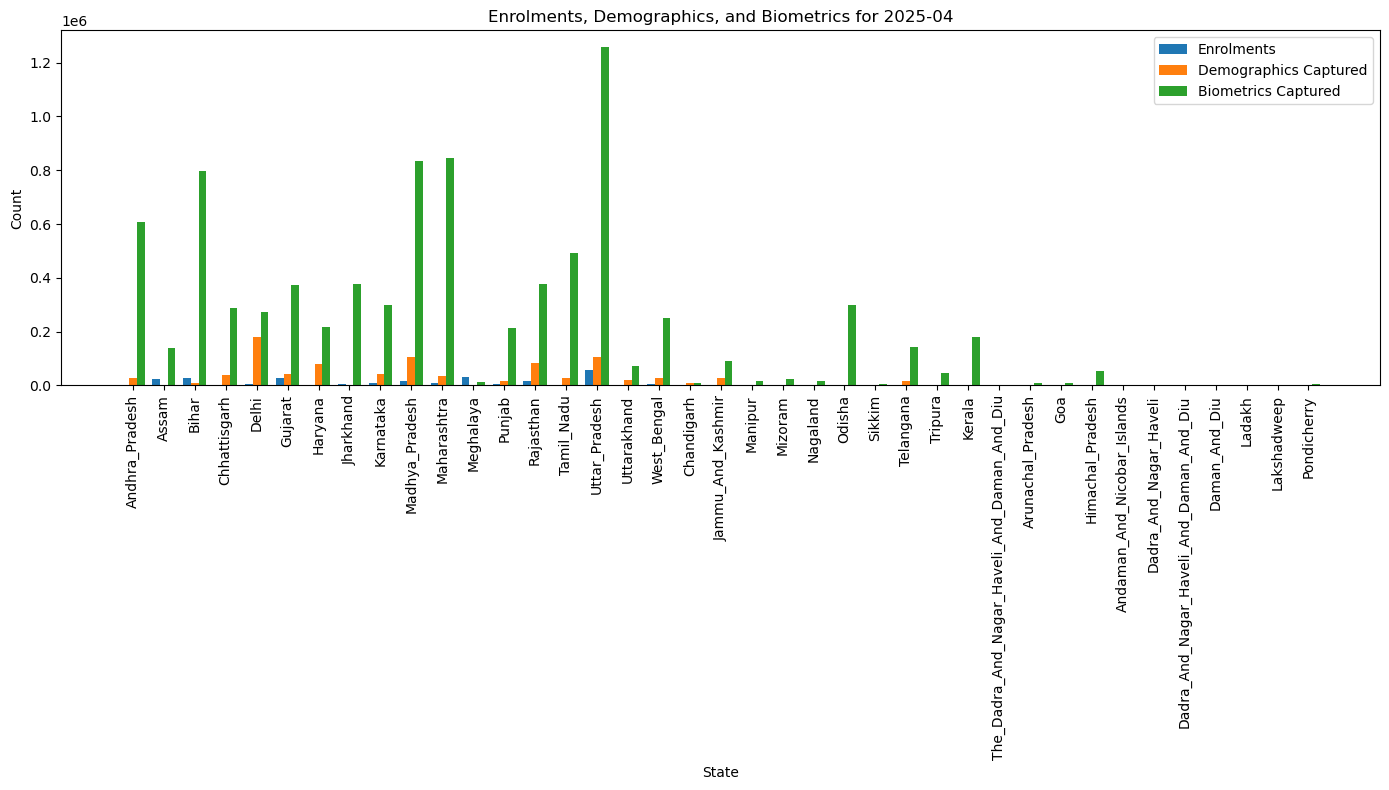

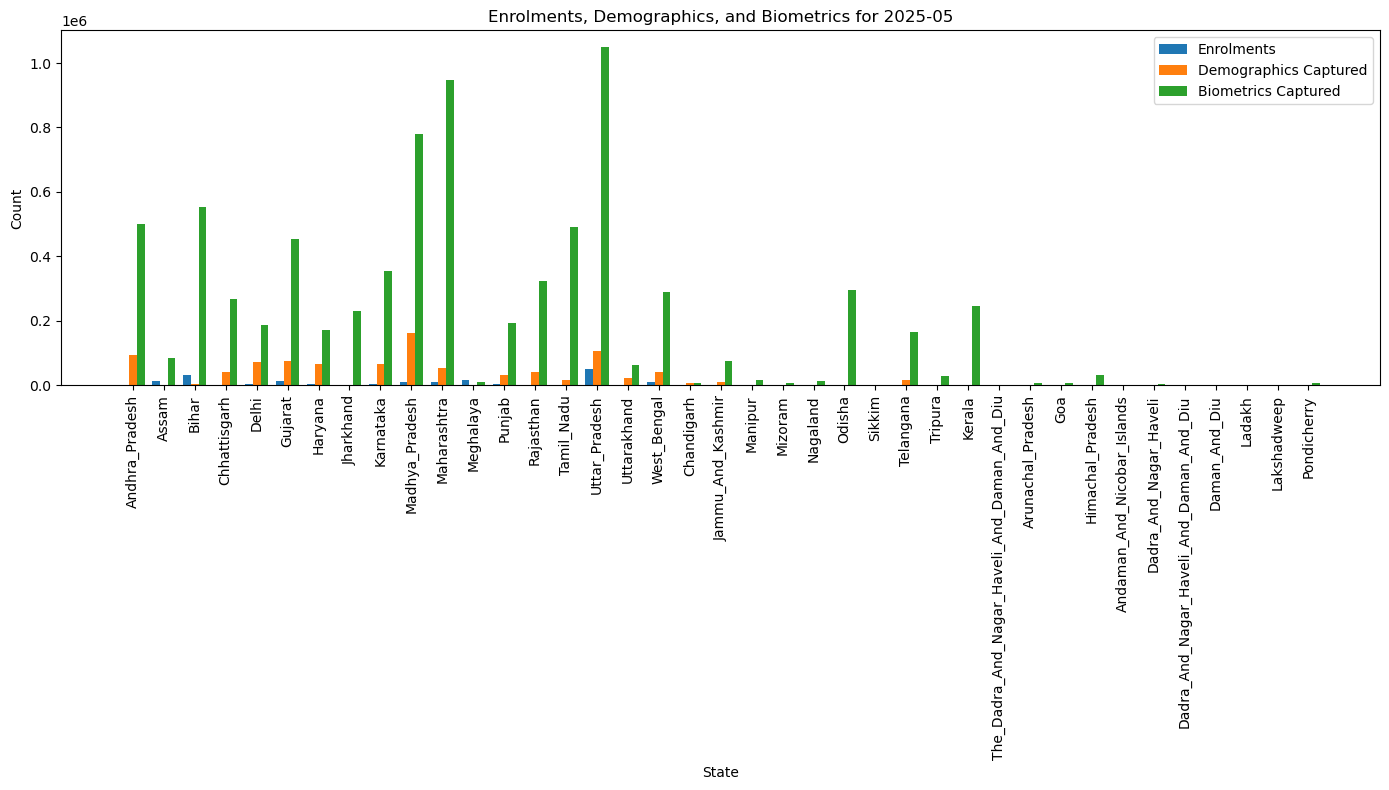

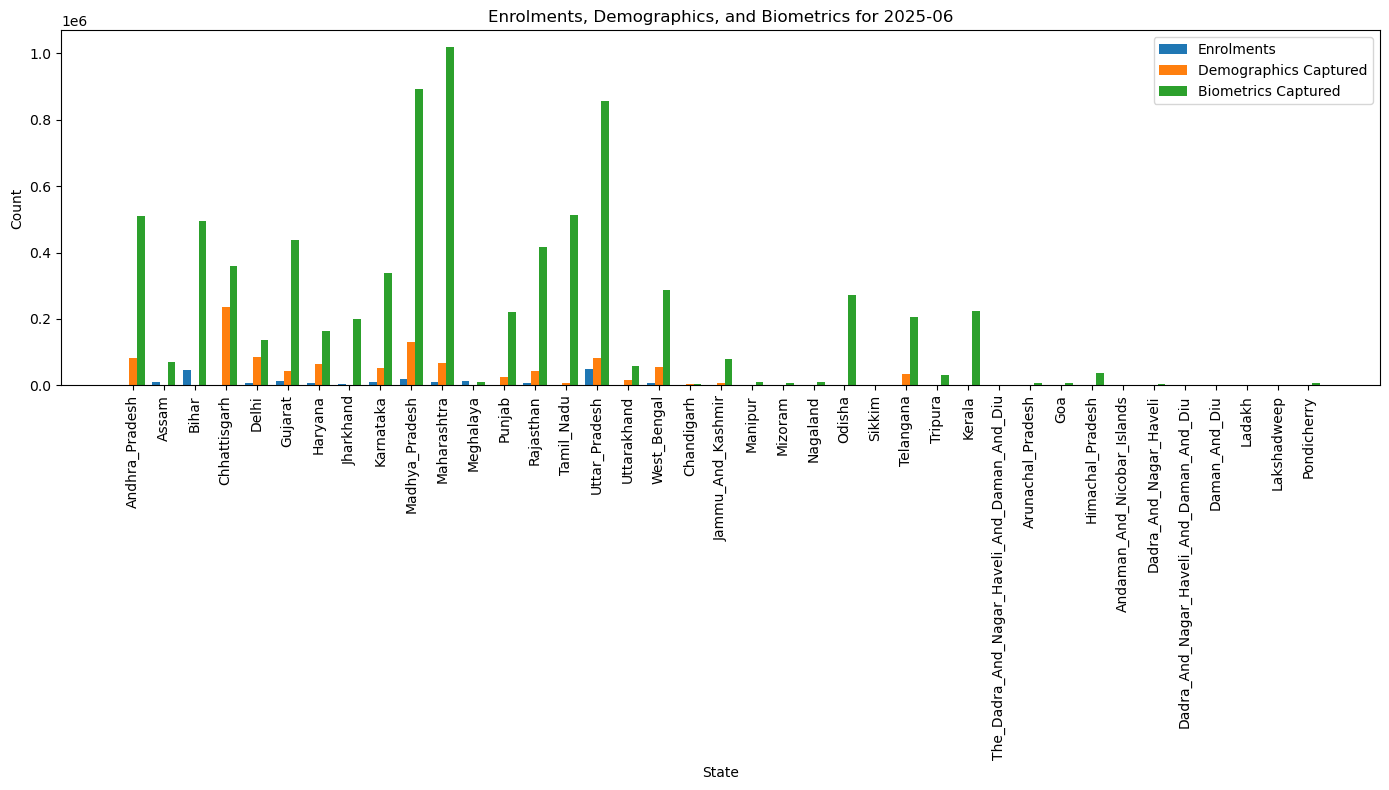

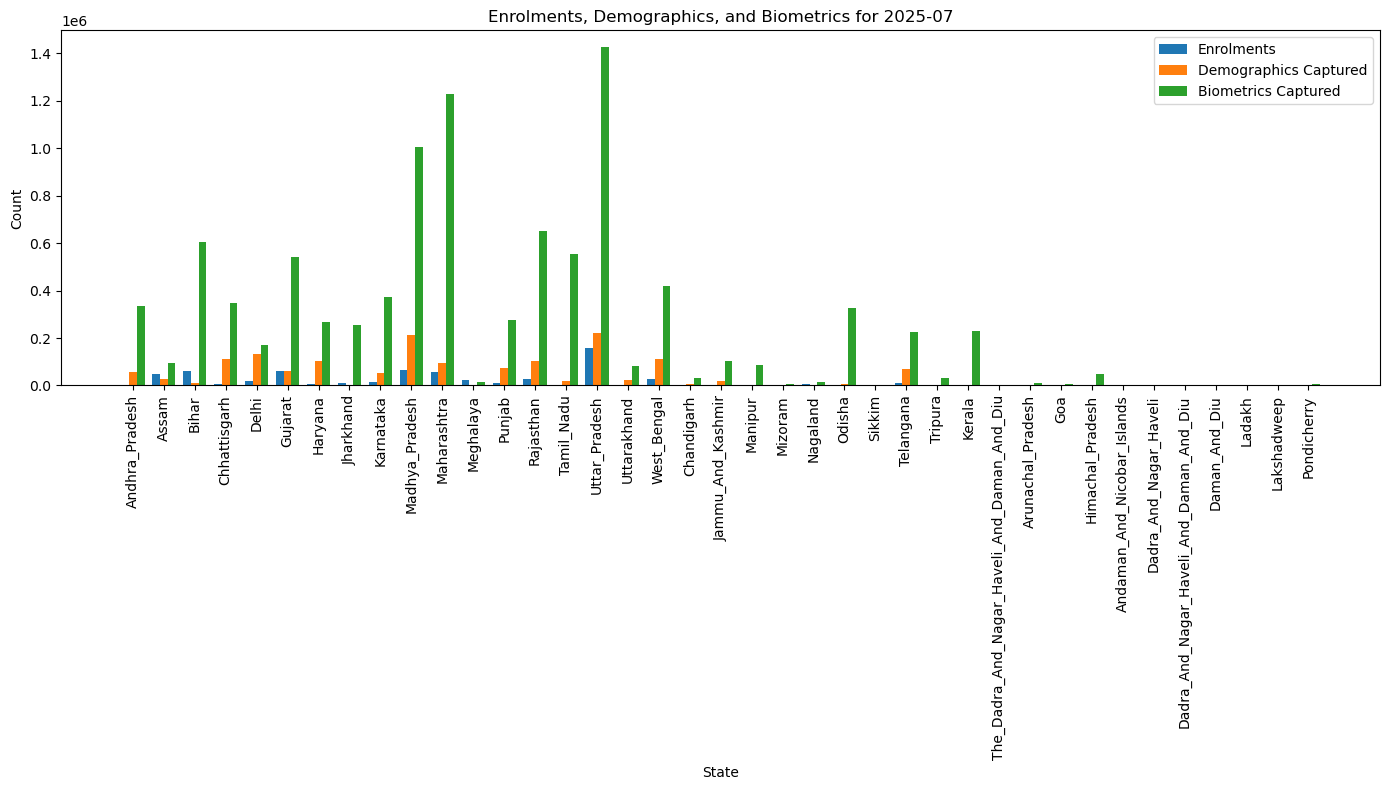

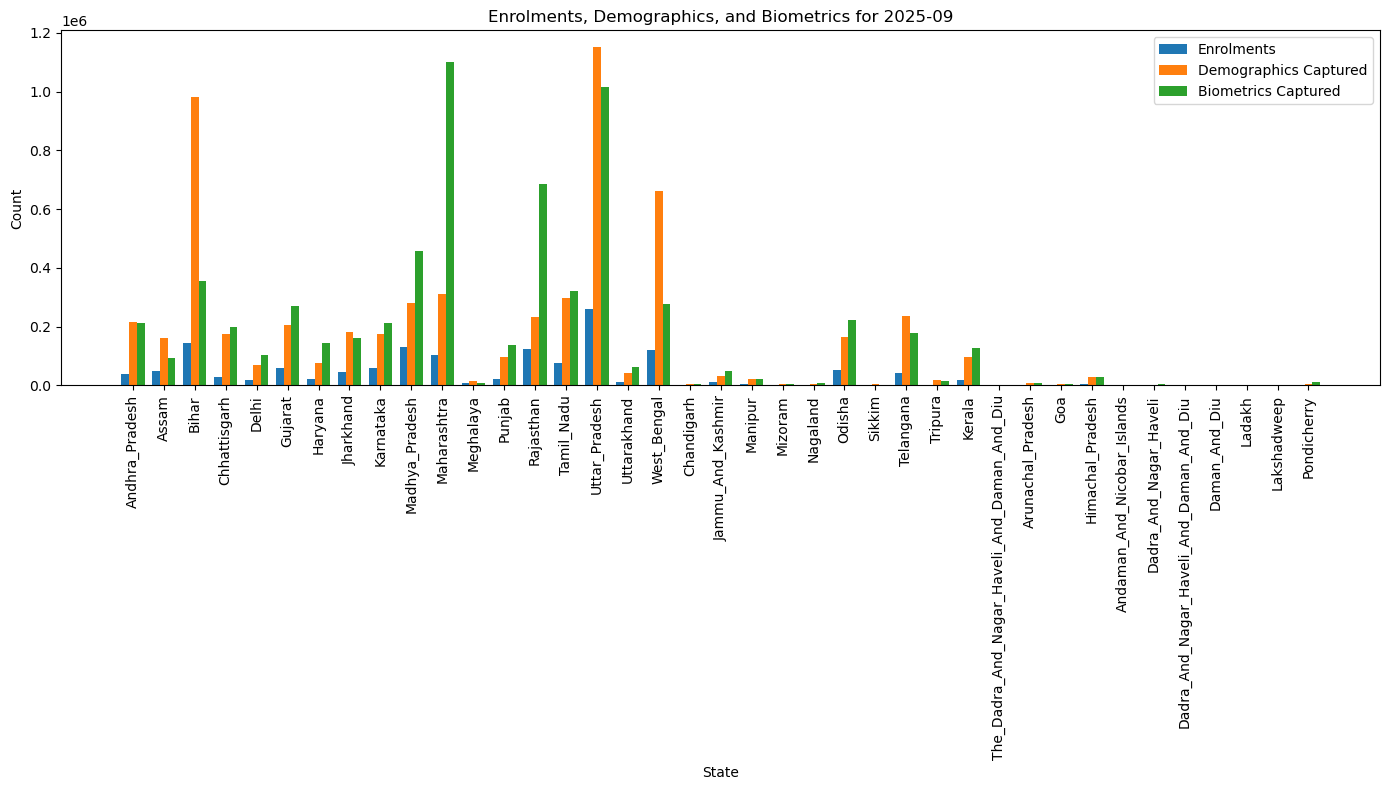

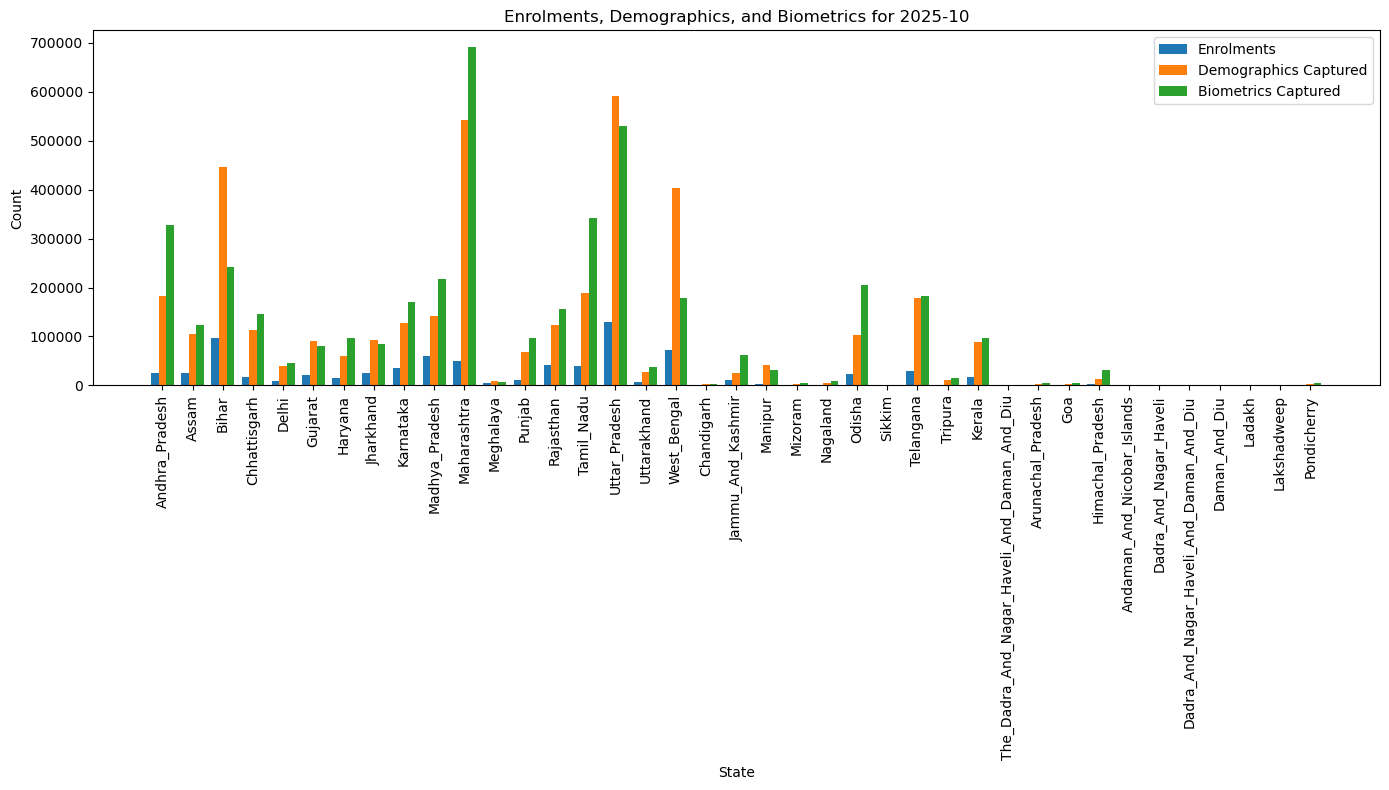

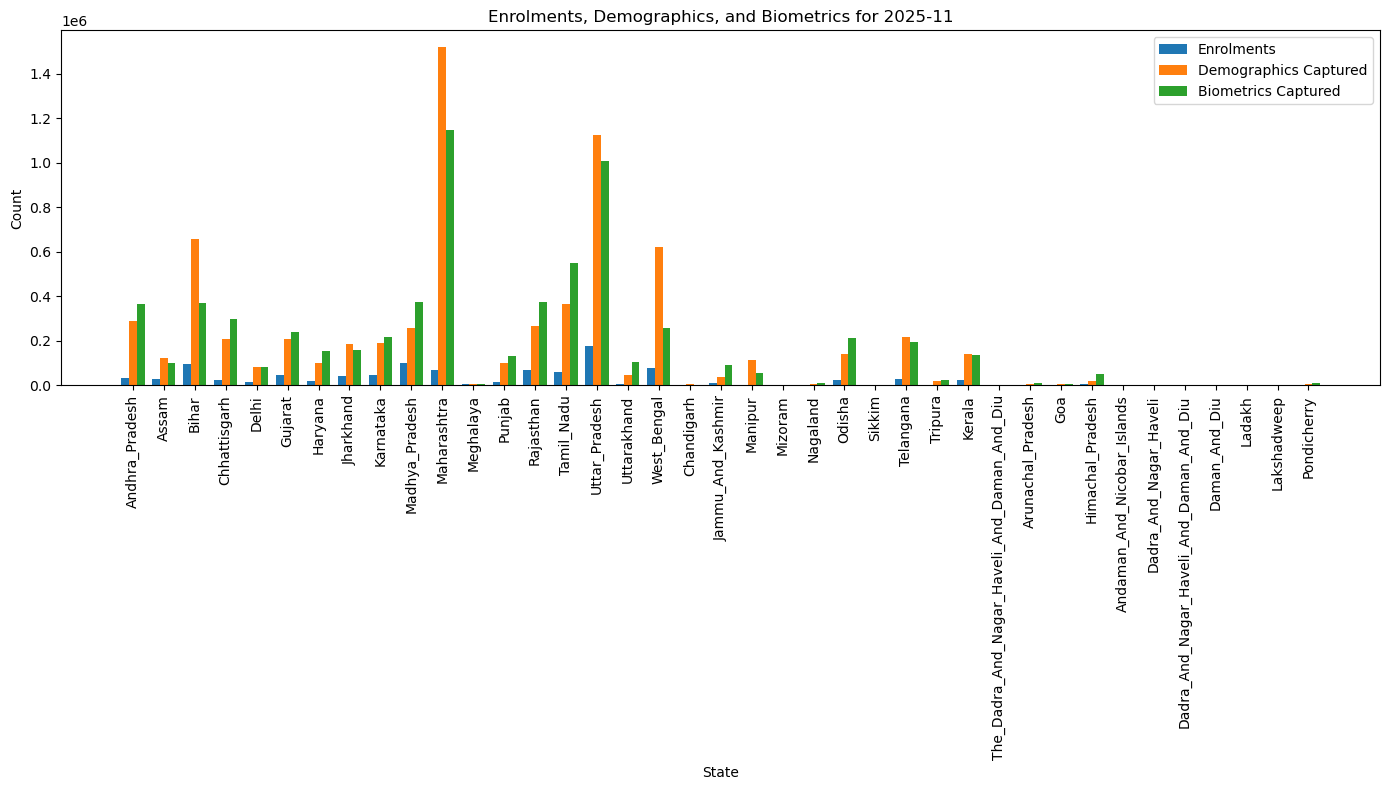

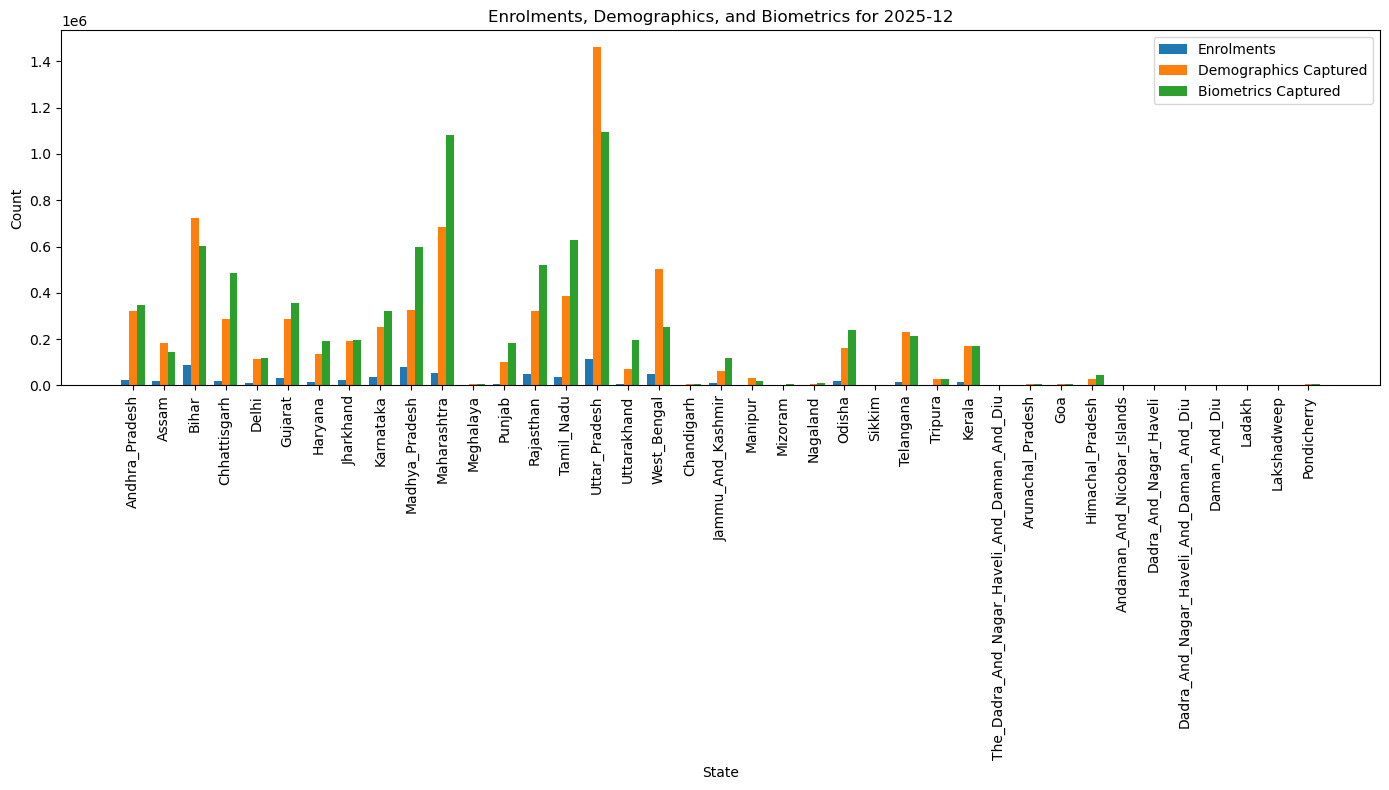

In [33]:
# plot Monthly Enrolments, Demographics, and Biometrics vs states in a grouped bar chart
states = monthly_enrolments['state'].unique()
for month in months.astype(str):
    plt.figure(figsize=(14, 8))
    enrolment_counts = monthly_enrolments[monthly_enrolments['enrolment_month'].astype(str) == month].set_index('state')[['age_0_5', 'age_5_17', 'age_18_greater']].sum(axis=1)
    demographic_counts = monthly_demographics[monthly_demographics['demographic_month'].astype(str) == month].set_index('state')[['demo_age_5_17', 'demo_age_17_']].sum(axis=1)
    biometric_counts = monthly_biometrics[monthly_biometrics['biometric_month'].astype(str) == month].set_index('state')[['bio_age_5_17', 'bio_age_17_']].sum(axis=1)
    
    x = np.arange(len(states))
    width = 0.25
    
    plt.bar(x - width, enrolment_counts.reindex(states, fill_value=0), width, label='Enrolments')
    plt.bar(x, demographic_counts.reindex(states, fill_value=0), width, label='Demographics Captured')
    plt.bar(x + width, biometric_counts.reindex(states, fill_value=0), width, label='Biometrics Captured')
    
    plt.xlabel('State')
    plt.ylabel('Count')
    plt.title(f'Enrolments, Demographics, and Biometrics for {month}')
    plt.xticks(x, states, rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'graphs/{month}_data_perstate.png', dpi=300)
    plt.show()

In [34]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Aggregate enrolments per state per month
data = (
    monthly_enrolments
    .groupby(['enrolment_month', 'state'])[
        ['age_0_5', 'age_5_17', 'age_18_greater']
    ]
    .sum()
    .sum(axis=1)
    .reset_index(name='count')
)

months = sorted(data['enrolment_month'].astype(str).unique())
states = sorted(data['state'].unique())


In [35]:
month_idx = {m: i for i, m in enumerate(months)}
state_idx = {s: i for i, s in enumerate(states)}

xs = data['enrolment_month'].astype(str).map(month_idx)
ys = data['state'].map(state_idx)
zs = np.zeros(len(data))                 # base of bars
dx = dy = 0.6
dz = data['count']


C:\Users\hp\AppData\Local\Temp\ipykernel_7052\3836198278.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


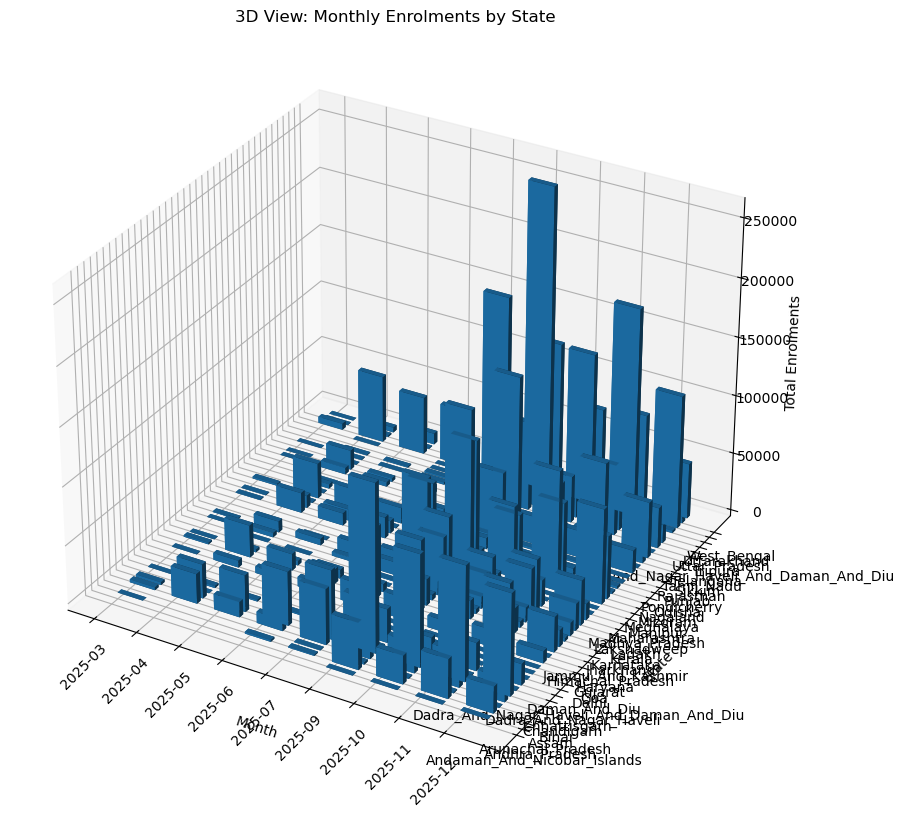

In [36]:
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(xs, ys, zs, dx, dy, dz)

ax.set_xlabel('Month')
ax.set_ylabel('State')
ax.set_zlabel('Total Enrolments')
ax.set_title('3D View: Monthly Enrolments by State')

ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45)

ax.set_yticks(range(len(states)))
ax.set_yticklabels(states)

plt.tight_layout()
plt.show()
